Philip Fowler
2025 17 07
A notebook to investigate methods for comparing different datasets

# Import Libraries

In [ ]:
# First, let us import a bunch of libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import loadmat
import plotly.express as px
from statsmodels.tsa.stattools import adfuller
from pandas.plotting import lag_plot
from scipy.optimize import linear_sum_assignment
from scipy.stats import ks_2samp
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import grangercausalitytests
import networkx as nx
import h5py
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from matplotlib.backends.backend_pdf import PdfPages
import os
from matplotlib import image as mpimg


In [122]:
# Define some constants
ground_truth = 'data/bGround_Truth_data_10trials_100stims_180000ms.hdf5'
submission = 'data/bNeuron_A_Weight_changed_10trials_100stims_180000ms.hdf5'

In [123]:
for filename in [ground_truth, submission]:
    print(f"\nExamining file: {filename}")
    with h5py.File(filename, 'r') as f:
        print("Keys:", list(f.keys()))
        for key in f.keys():
            data_item = f[key]
            print(f"{key}: type={type(data_item)}", end='')
            if isinstance(data_item, h5py.Dataset):
                print(f", shape={data_item.shape}")
            else:
                print()



Examining file: data/bGround_Truth_data_10trials_100stims_180000ms.hdf5
Keys: ['trial_0', 'trial_1', 'trial_2', 'trial_3', 'trial_4', 'trial_5', 'trial_6', 'trial_7', 'trial_8', 'trial_9']
trial_0: type=<class 'h5py._hl.group.Group'>
trial_1: type=<class 'h5py._hl.group.Group'>
trial_2: type=<class 'h5py._hl.group.Group'>
trial_3: type=<class 'h5py._hl.group.Group'>
trial_4: type=<class 'h5py._hl.group.Group'>
trial_5: type=<class 'h5py._hl.group.Group'>
trial_6: type=<class 'h5py._hl.group.Group'>
trial_7: type=<class 'h5py._hl.group.Group'>
trial_8: type=<class 'h5py._hl.group.Group'>
trial_9: type=<class 'h5py._hl.group.Group'>

Examining file: data/bNeuron_A_Weight_changed_10trials_100stims_180000ms.hdf5
Keys: ['trial_0', 'trial_1', 'trial_2', 'trial_3', 'trial_4', 'trial_5', 'trial_6', 'trial_7', 'trial_8', 'trial_9']
trial_0: type=<class 'h5py._hl.group.Group'>
trial_1: type=<class 'h5py._hl.group.Group'>
trial_2: type=<class 'h5py._hl.group.Group'>
trial_3: type=<class 'h5py._h

In [124]:
for filename in [ground_truth, submission]:
    print(f"\nExamining trial groups in file: {filename}")
    with h5py.File(filename, 'r') as f:
        for trial_name in f.keys():
            if 'trial' in trial_name.lower():
                trial_group = f[trial_name]
                print(f"Keys in {trial_name} group:", list(trial_group.keys()))
                for name, item in trial_group.items():
                    if isinstance(item, h5py.Dataset):
                        print(f"Dataset '{name}' in {trial_name} shape:", item.shape)
                    else:
                        print(f"'{name}' in {trial_name} is a group, not a dataset.")



Examining trial groups in file: data/bGround_Truth_data_10trials_100stims_180000ms.hdf5
Keys in trial_0 group: ['data']
Dataset 'data' in trial_0 shape: (180000, 11)
Keys in trial_1 group: ['data']
Dataset 'data' in trial_1 shape: (180000, 11)
Keys in trial_2 group: ['data']
Dataset 'data' in trial_2 shape: (180000, 11)
Keys in trial_3 group: ['data']
Dataset 'data' in trial_3 shape: (180000, 11)
Keys in trial_4 group: ['data']
Dataset 'data' in trial_4 shape: (180000, 11)
Keys in trial_5 group: ['data']
Dataset 'data' in trial_5 shape: (180000, 11)
Keys in trial_6 group: ['data']
Dataset 'data' in trial_6 shape: (180000, 11)
Keys in trial_7 group: ['data']
Dataset 'data' in trial_7 shape: (180000, 11)
Keys in trial_8 group: ['data']
Dataset 'data' in trial_8 shape: (180000, 11)
Keys in trial_9 group: ['data']
Dataset 'data' in trial_9 shape: (180000, 11)

Examining trial groups in file: data/bNeuron_A_Weight_changed_10trials_100stims_180000ms.hdf5
Keys in trial_0 group: ['data']
Data

# Create dataframes/arrays for each trial

In [125]:
for fname, prefix in [(ground_truth, 'gt'), (submission, 'sub')]:
    with h5py.File(fname, 'r') as f:
        for trial_name in f.keys():
            if trial_name.startswith('trial_'):
                trial_group = f[trial_name]
                for name, item in trial_group.items():
                    if isinstance(item, h5py.Dataset):
                        data = item[()]
                        if data.ndim == 2:
                            columns = [f'neuron{i+1}' for i in range(data.shape[1])]
                            df = pd.DataFrame(data, columns=columns)
                        else:
                            df = pd.DataFrame(data)
                        # Rename columns
                        new_columns = ['time']
                        for i in range(1, (len(columns))//2 + 1):
                            new_columns.append(f'neuron{i}_spike')
                            new_columns.append(f'neuron{i}_mempot')
                        df.columns = new_columns[:df.shape[1]]
                        # Name dataframe according to file and trial
                        trial_idx = trial_name.split('_')[1]
                        globals()[f"{prefix}_trial{trial_idx}_df"] = df

In [126]:
# Automatically collect all gt and sub trial dataframes based on variable names
gt_trials = [globals()[name] for name in sorted(globals()) if name.startswith('gt_trial') and name.endswith('_df')]
sub_trials = [globals()[name] for name in sorted(globals()) if name.startswith('sub_trial') and name.endswith('_df')]

NUM_GT_TRIALS = len(gt_trials)
NUM_SUB_TRIALS = len(sub_trials)
num_gt_neurons = len([col for col in gt_trials[0].columns if col.endswith('_spike')])
num_sub_neurons = len([col for col in sub_trials[0].columns if col.endswith('_spike')])

### Create Concatenated DataFrames for all trials

In [127]:
gt_concat_df = pd.concat(gt_trials, ignore_index=True)
sub_concat_df = pd.concat(sub_trials, ignore_index=True)

### Find average firing rates

In [128]:
bin_size = 500  
def compute_psth(trials, spike_columns, bin_size):
    num_bins = trials[0].shape[0] // bin_size
    num_neurons = len(spike_columns)
    binned_spikes = np.zeros((len(trials), num_bins, num_neurons))
    for t, trial_df in enumerate(trials):
        for n, col in enumerate(spike_columns):
            spikes = trial_df[col].values[:num_bins * bin_size]
            binned_spikes[t, :, n] = spikes.reshape(num_bins, bin_size).sum(axis=1)
    mean_spikes = binned_spikes.mean(axis=0)
    firing_rate = mean_spikes / bin_size 
    return firing_rate

psth_gt = compute_psth(gt_trials, spike_columns, bin_size)
psth_sub = compute_psth(sub_trials, spike_columns, bin_size)
# note: These are numpy arrays not dataframes

In [129]:
gt_concat_df.shape, sub_concat_df.shape

((1800000, 11), (1800000, 11))

In [130]:
gt_trial0_df.shape, sub_trial0_df.shape


((180000, 11), (180000, 11))

In [131]:
psth_gt.shape, psth_sub.shape

((360, 5), (360, 5))

# Metrics
### These metrics use the concatenated dataframes

This raster plot is not perfect.  I shortened the length of the red lines so that the black were visible. 

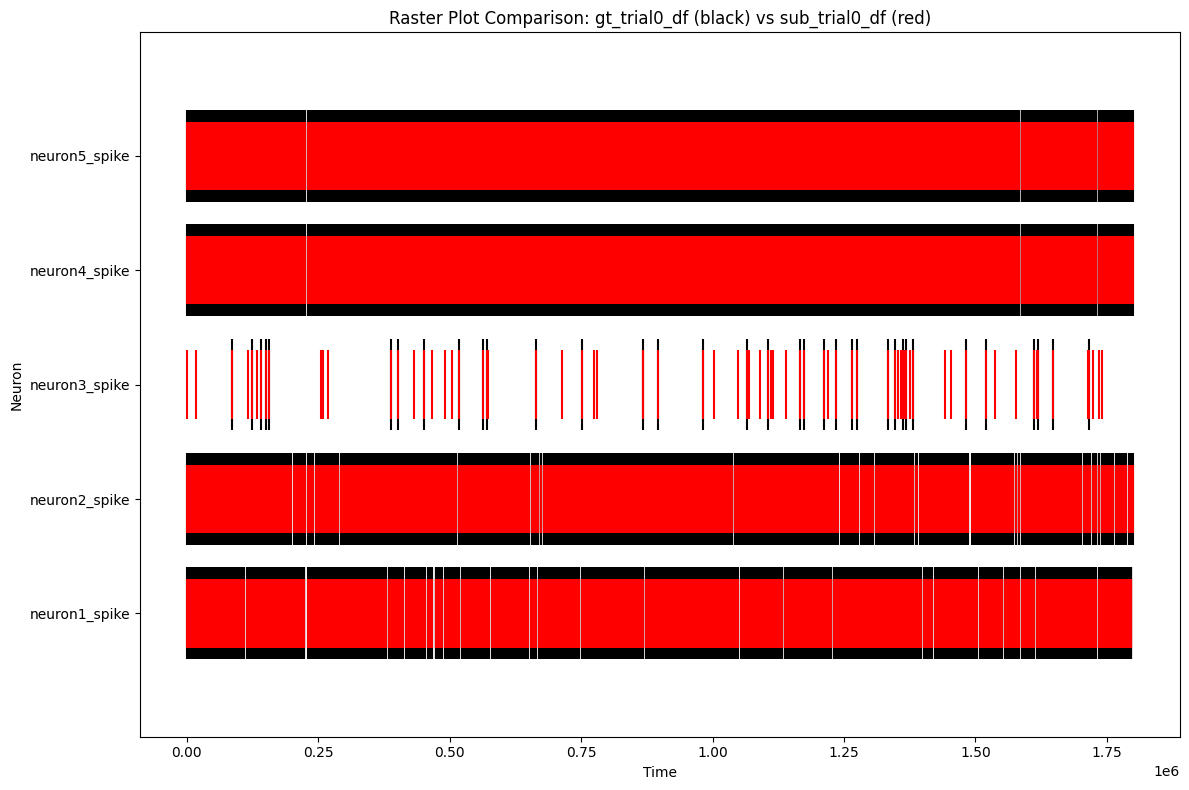

In [132]:
spike_columns = [col for col in gt_concat_df.columns if col.endswith('_spike')]
gt_spike_times_per_neuron = [gt_concat_df.index[gt_concat_df[col] == 1].to_numpy() for col in spike_columns]
sub_spike_times_per_neuron = [sub_concat_df.index[sub_concat_df[col] == 1].to_numpy() for col in spike_columns]

plt.figure(figsize=(12, 8))
plt.eventplot(gt_spike_times_per_neuron, orientation='horizontal', colors='black', linelengths=0.8, label='Ground Truth')
plt.eventplot(sub_spike_times_per_neuron, orientation='horizontal', colors='red', linelengths=0.6, label='Submission')
plt.yticks(np.arange(len(spike_columns)), spike_columns)
plt.xlabel('Time')
plt.ylabel('Neuron')
plt.title('Raster Plot Comparison: gt_trial0_df (black) vs sub_trial0_df (red)')
plt.tight_layout()
plt.show()


This raster plot only plots the difference between the ground truth and the submission

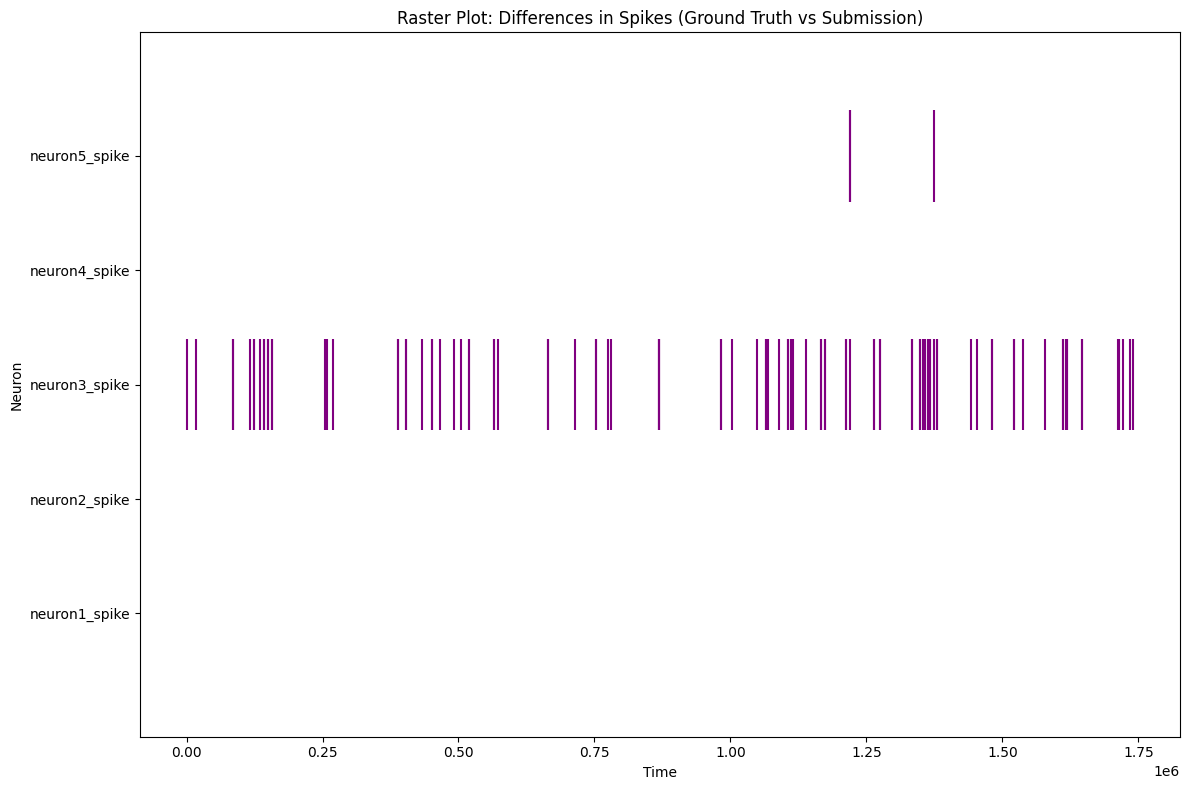

In [133]:
diff_spike_times_per_neuron = []
for gt_spikes, sub_spikes in zip(gt_spike_times_per_neuron, sub_spike_times_per_neuron):
    diff_times = np.setxor1d(gt_spikes, sub_spikes)
    diff_spike_times_per_neuron.append(diff_times)

plt.figure(figsize=(12, 8))
plt.eventplot(diff_spike_times_per_neuron, orientation='horizontal', colors='purple', linelengths=0.8)
plt.yticks(np.arange(len(spike_columns)), spike_columns)
plt.xlabel('Time')
plt.ylabel('Neuron')
plt.title('Raster Plot: Differences in Spikes (Ground Truth vs Submission)')
plt.tight_layout()
plt.savefig('charts/raster_difference.png', format='png')
plt.show()


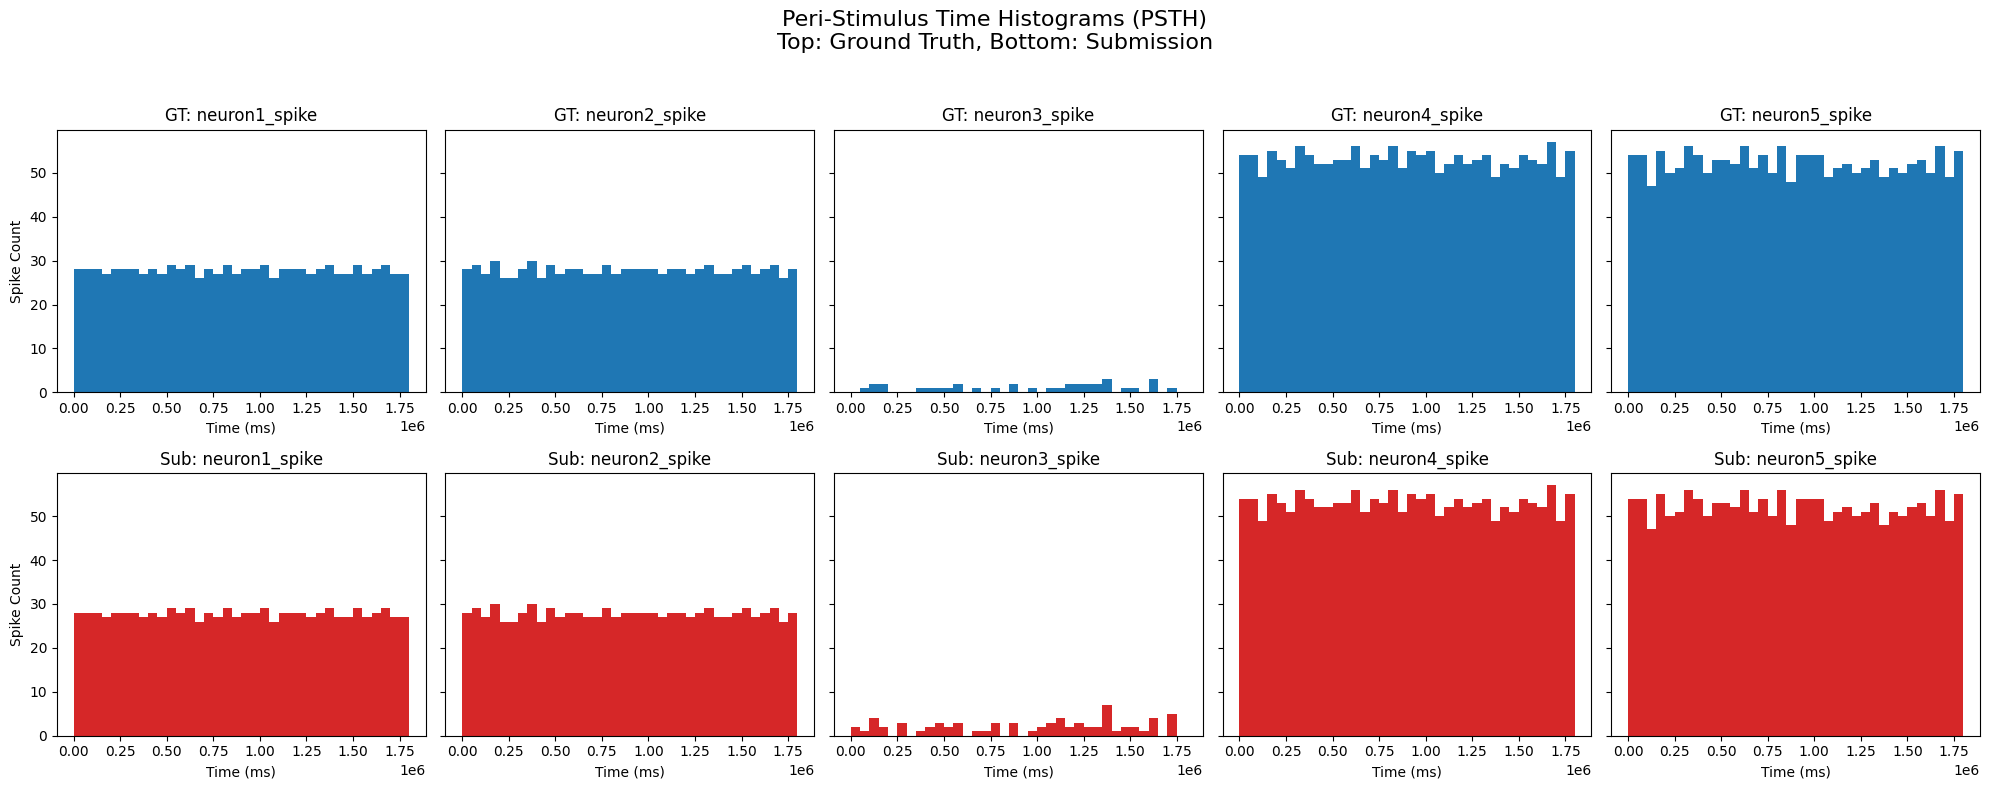

In [134]:
peri_bin_size = 50000
num_bins = gt_concat_df.shape[0] // peri_bin_size
spike_columns = [col for col in gt_concat_df.columns if col.endswith('_spike')]
num_neurons = len(spike_columns)
time_bins = np.arange(num_bins) * peri_bin_size

def compute_psth_concat(df, spike_columns, num_bins, peri_bin_size, num_neurons):
    binned_spikes = np.zeros((num_bins, num_neurons))
    for n, col in enumerate(spike_columns):
        spikes = df[col].values[:num_bins * peri_bin_size]
        binned_spikes[:, n] = spikes.reshape(num_bins, peri_bin_size).sum(axis=1)
    return binned_spikes

mean_gt_spike_counts = compute_psth_concat(gt_concat_df, spike_columns, num_bins, peri_bin_size, num_neurons)
mean_sub_spike_counts = compute_psth_concat(sub_concat_df, spike_columns, num_bins, peri_bin_size, num_neurons)

fig, axes = plt.subplots(2, num_neurons, figsize=(4*num_neurons, 8), sharey=True)
for i, col in enumerate(spike_columns):
    axes[0, i].bar(time_bins, mean_gt_spike_counts[:, i], width=peri_bin_size, align='edge', color='tab:blue')
    axes[0, i].set_title(f'GT: {col}')
    axes[0, i].set_xlabel('Time (ms)')
    if i == 0:
        axes[0, i].set_ylabel('Spike Count')
    axes[1, i].bar(time_bins, mean_sub_spike_counts[:, i], width=peri_bin_size, align='edge', color='tab:red')
    axes[1, i].set_title(f'Sub: {col}')
    axes[1, i].set_xlabel('Time (ms)')
    if i == 0:
        axes[1, i].set_ylabel('Spike Count')
plt.suptitle('Peri-Stimulus Time Histograms (PSTH)\nTop: Ground Truth, Bottom: Submission', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('charts/peri_stim_histogram.png', format='png')
plt.show()


In [135]:
ks_results = {}
for col in spike_columns:
    gt_spikes = gt_concat_df[col].values
    sub_spikes = sub_concat_df[col].values
    stat, pvalue = ks_2samp(gt_spikes, sub_spikes)
    ks_results[col] = {'statistic': stat, 'pvalue': pvalue}
    print(f"{col}: KS statistic={stat:.4f}, p-value={pvalue:.4e}")

neuron1_spike: KS statistic=0.0000, p-value=1.0000e+00
neuron2_spike: KS statistic=0.0000, p-value=1.0000e+00
neuron3_spike: KS statistic=0.0000, p-value=1.0000e+00
neuron4_spike: KS statistic=0.0000, p-value=1.0000e+00
neuron5_spike: KS statistic=0.0000, p-value=1.0000e+00


### PSTH Metrics

In [136]:
pearson_corrs = []
for i in range(num_neurons):
    corr, _ = pearsonr(psth_gt[:, i], psth_sub[:, i])
    pearson_corrs.append(corr)
    print(f"Neuron {i+1}: Pearson correlation = {corr:.4f}")



Neuron 1: Pearson correlation = 1.0000
Neuron 2: Pearson correlation = 1.0000
Neuron 3: Pearson correlation = 0.6490
Neuron 4: Pearson correlation = 1.0000
Neuron 5: Pearson correlation = 0.9997


In [137]:

mse_per_neuron = []
for i in range(num_neurons):
    mse = mean_squared_error(psth_gt[:, i], psth_sub[:, i])
    mse_per_neuron.append(mse)
    print(f"Neuron {i+1}: MSE = {mse:.6e}")



Neuron 1: MSE = 0.000000e+00
Neuron 2: MSE = 0.000000e+00
Neuron 3: MSE = 4.555556e-09
Neuron 4: MSE = 0.000000e+00
Neuron 5: MSE = 1.111111e-10


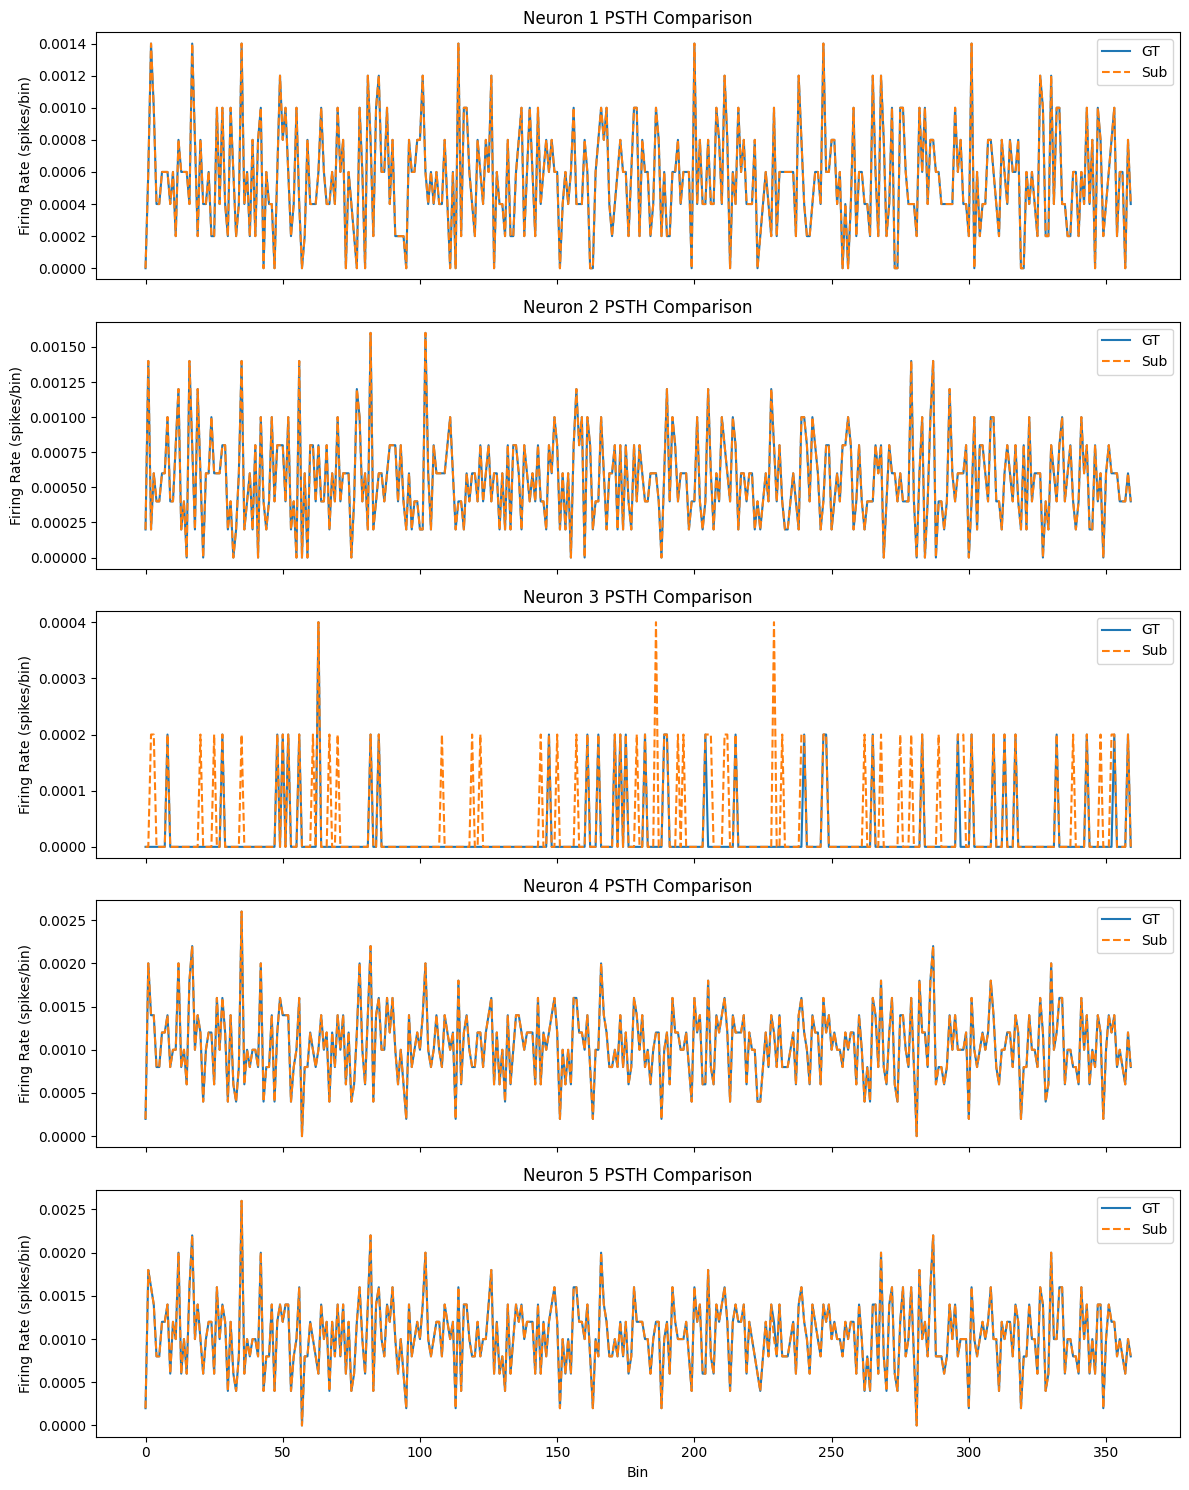

In [138]:
fig, axes = plt.subplots(num_neurons, 1, figsize=(12, 3 * num_neurons), sharex=True)
for i in range(num_neurons):
    axes[i].plot(psth_gt[:, i], label='GT', linestyle='-')
    axes[i].plot(psth_sub[:, i], label='Sub', linestyle='--')
    axes[i].set_ylabel('Firing Rate (spikes/bin)')
    axes[i].set_title(f'Neuron {i+1} PSTH Comparison')
    axes[i].legend()
axes[-1].set_xlabel('Bin')
plt.tight_layout()
plt.show()

### Rate Based Metrics

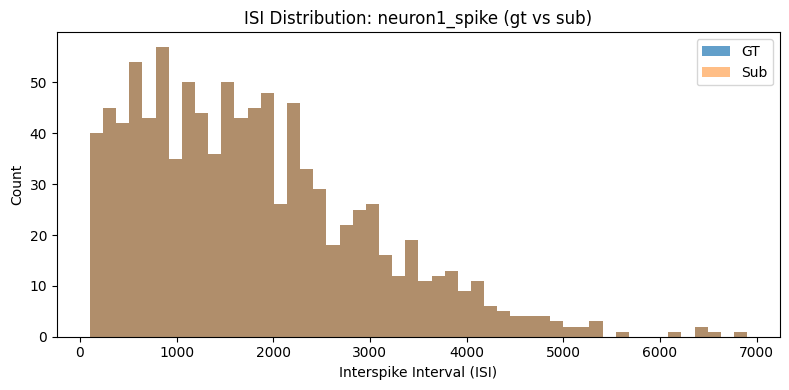

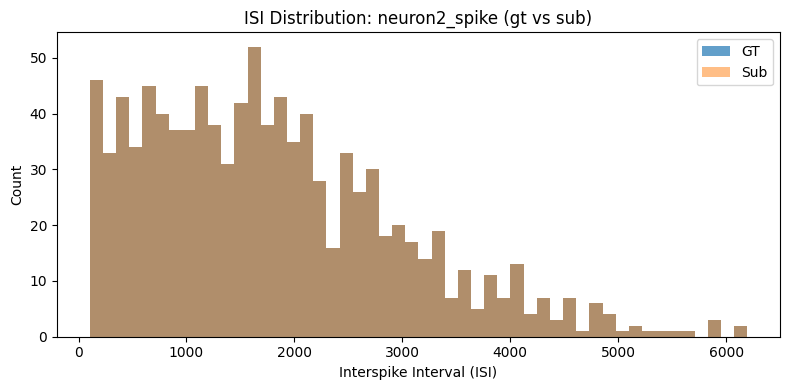

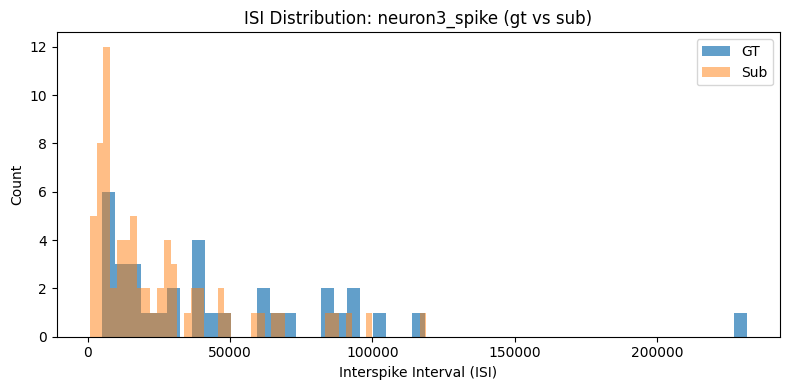

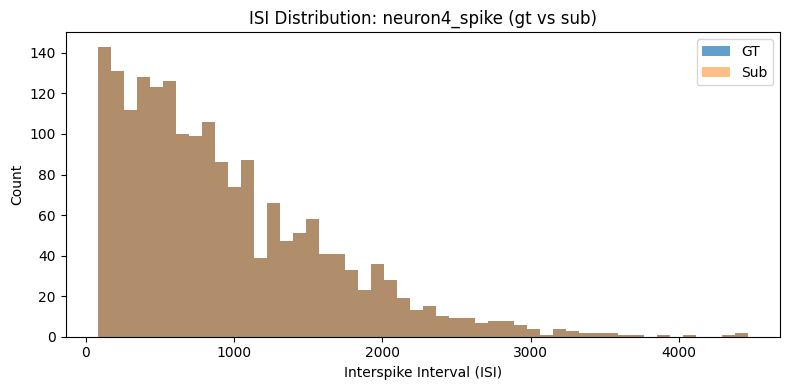

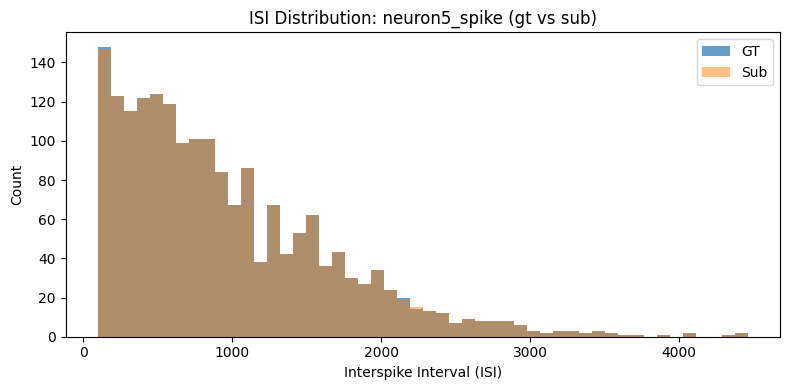

In [139]:
def plot_isi_per_neuron_compare(gt_df, sub_df, spike_columns):
    for col in spike_columns:
        gt_spike_times = np.where(gt_df[col].values == 1)[0]
        sub_spike_times = np.where(sub_df[col].values == 1)[0]
        gt_isis = np.diff(gt_spike_times)
        sub_isis = np.diff(sub_spike_times)
        plt.figure(figsize=(8, 4))
        plt.hist(gt_isis, bins=50, color='tab:blue', alpha=0.7, label='GT')
        plt.hist(sub_isis, bins=50, color='tab:orange', alpha=0.5, label='Sub')
        plt.xlabel('Interspike Interval (ISI)')
        plt.ylabel('Count')
        plt.title(f'ISI Distribution: {col} (gt vs sub)')
        plt.legend()
        plt.tight_layout()
        plt.savefig(f'charts/isi_dist_{col.replace("_spike", "")}.png', format='png')
        plt.show()

plot_isi_per_neuron_compare(gt_concat_df, sub_concat_df, spike_columns)


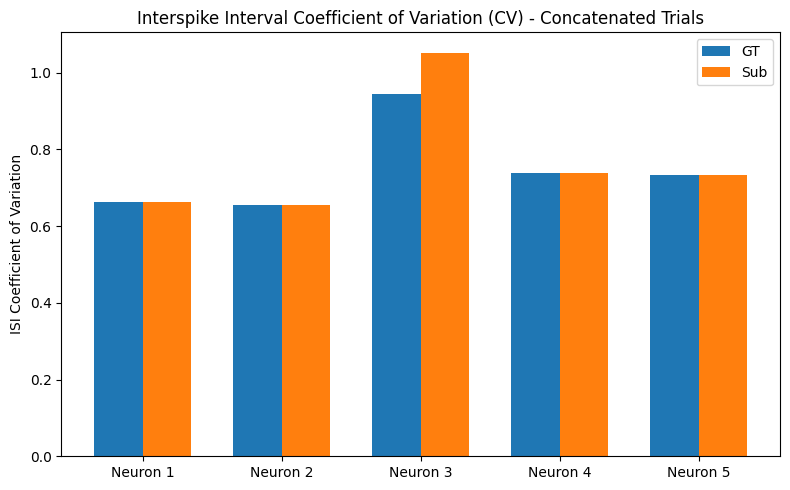

In [140]:
def compute_isi_cv(df, spike_columns):
    cvs = []
    for col in spike_columns:
        spike_times = np.where(df[col].values == 1)[0]
        isis = np.diff(spike_times)
        if len(isis) > 1:
            cv = np.std(isis) / np.mean(isis)
        else:
            cv = np.nan
        cvs.append(cv)
    return cvs

# Compute ISI CV for concatenated ground truth and submission dataframes
gt_cv_concat = compute_isi_cv(gt_concat_df, spike_columns)
sub_cv_concat = compute_isi_cv(sub_concat_df, spike_columns)

neuron_labels = [f'Neuron {i+1}' for i in range(num_neurons)]
x = np.arange(num_neurons)

plt.figure(figsize=(8, 5))
bar_width = 0.35
plt.bar(x - bar_width/2, gt_cv_concat, bar_width, label='GT', color='tab:blue')
plt.bar(x + bar_width/2, sub_cv_concat, bar_width, label='Sub', color='tab:orange')
plt.xticks(x, neuron_labels)
plt.ylabel('ISI Coefficient of Variation')
plt.title('Interspike Interval Coefficient of Variation (CV) - Concatenated Trials')
plt.legend()
plt.tight_layout()
plt.savefig('charts/isi_cv.png', format='png')
plt.show()


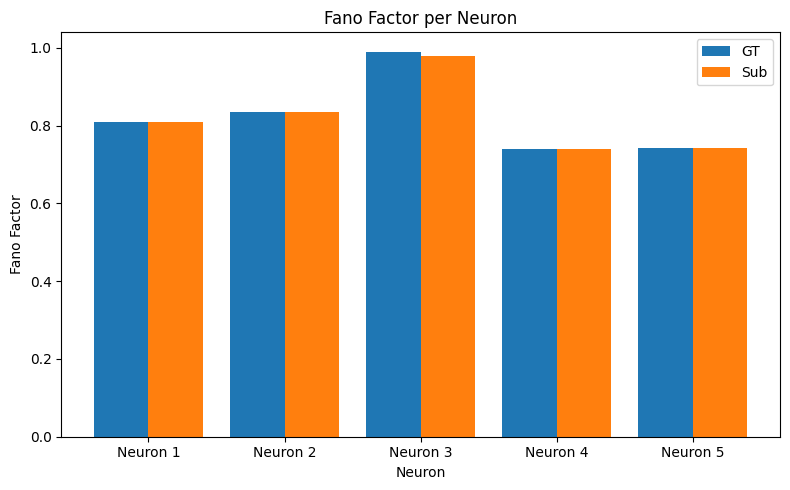

In [141]:
def spike_rate_and_fano(df, spike_columns, bin_size):
    num_bins = df.shape[0] // bin_size
    rates = []
    fanos = []
    for col in spike_columns:
        spikes = df[col].values[:num_bins * bin_size]
        binned_counts = spikes.reshape(num_bins, bin_size).sum(axis=1)
        rate = binned_counts.mean() / bin_size
        fano = np.var(binned_counts) / np.mean(binned_counts) if np.mean(binned_counts) > 0 else np.nan
        rates.append(rate)
        fanos.append(fano)
    return rates, fanos

gt_rates, gt_fanos = spike_rate_and_fano(gt_concat_df, spike_columns, bin_size)
sub_rates, sub_fanos = spike_rate_and_fano(sub_concat_df, spike_columns, bin_size)

plt.figure(figsize=(8, 5))
x = np.arange(len(spike_columns))
plt.bar(x - 0.2, gt_fanos, width=0.4, label='GT', color='tab:blue')
plt.bar(x + 0.2, sub_fanos, width=0.4, label='Sub', color='tab:orange')
plt.xticks(x, neuron_labels)
plt.ylabel('Fano Factor')
plt.xlabel('Neuron')
plt.title('Fano Factor per Neuron')
plt.legend()
plt.tight_layout()
plt.savefig('charts/fano_factor.png', format='png')
plt.show()

# Similarity Metrics

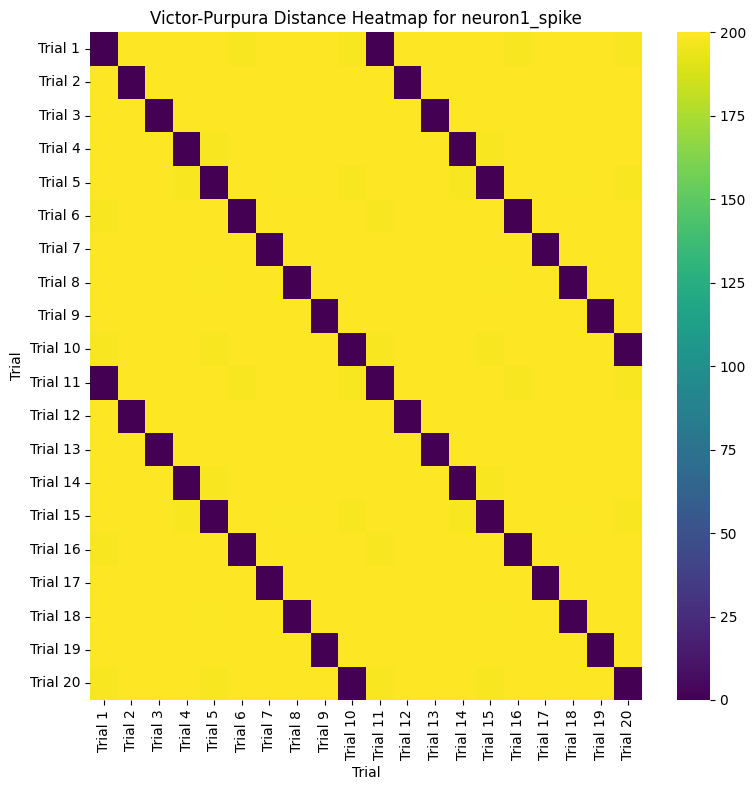

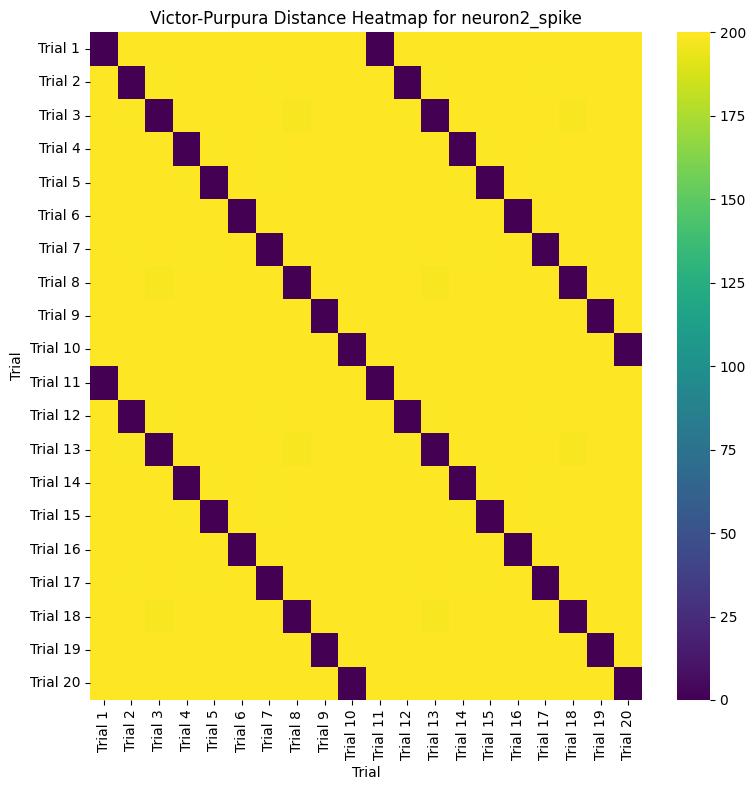

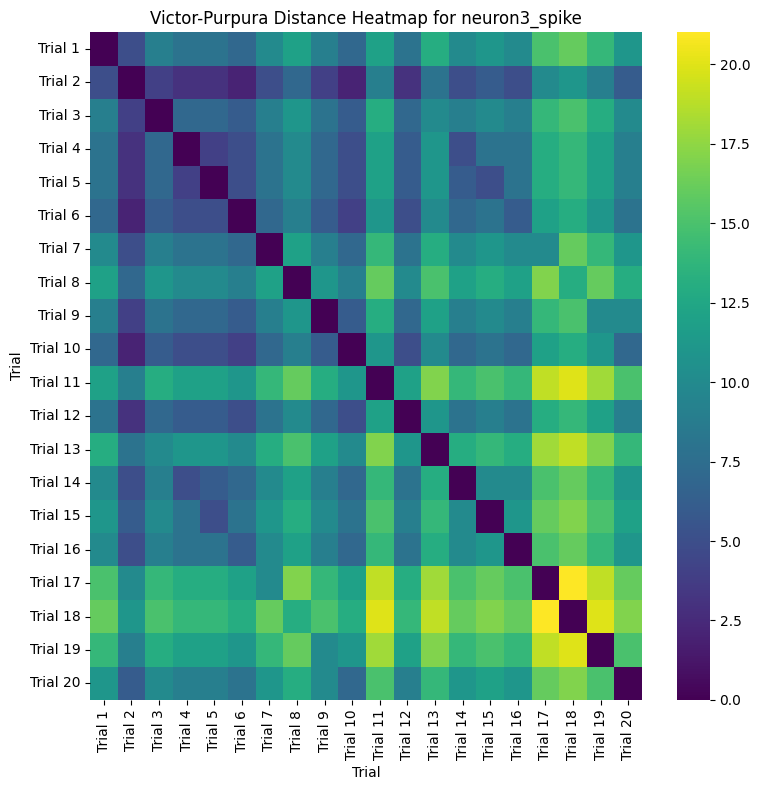

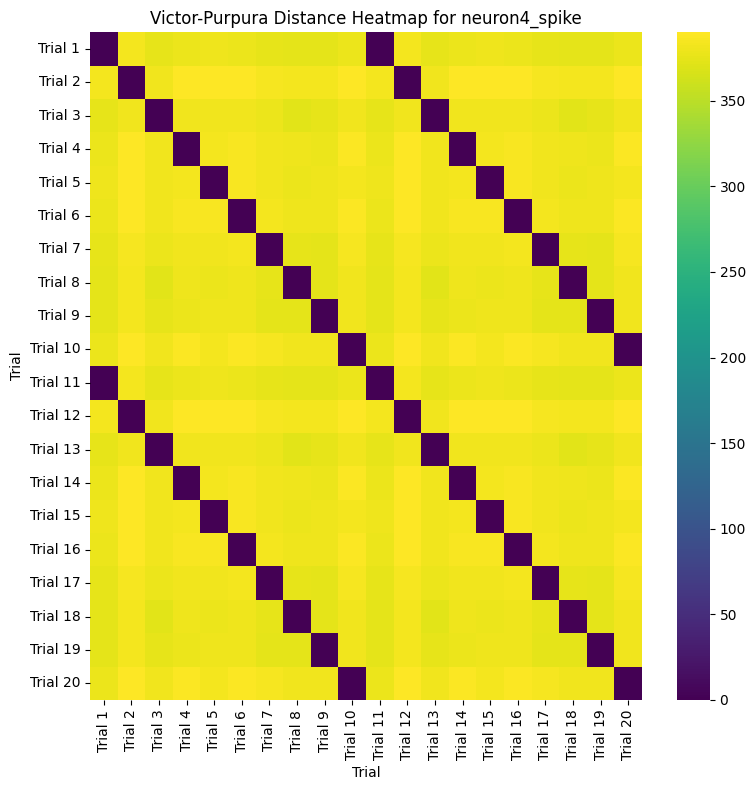

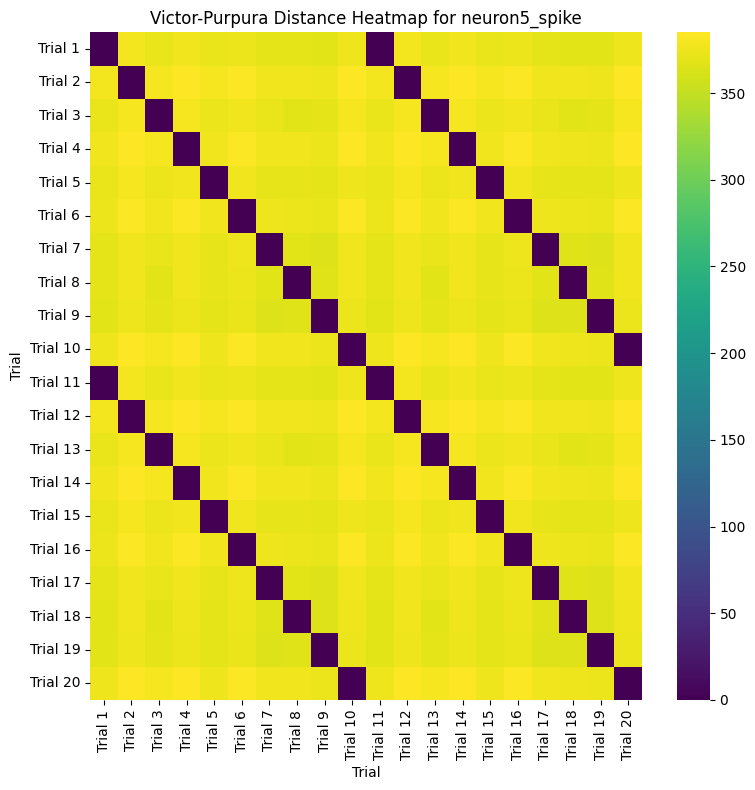

In [82]:

def victor_purpura_distance(trace1, trace2, q=1.0):
    spike_times1 = np.where(trace1 == 1)[0]
    spike_times2 = np.where(trace2 == 1)[0]
    n = len(spike_times1)
    m = len(spike_times2)
    dp = np.zeros((n+1, m+1))
    dp[:,0] = np.arange(n+1)
    dp[0,:] = np.arange(m+1)
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = q * abs(spike_times1[i-1] - spike_times2[j-1])
            dp[i,j] = min(
                dp[i-1,j] + 1,
                dp[i,j-1] + 1,
                dp[i-1,j-1] + cost
            )
    return dp[n,m]

spike_columns = [col for col in all_trials[0].columns if col.endswith('_spike')]

vp_distances = {}
for neuron in spike_columns:
    vp_distances[neuron] = []
    for i in range(len(all_trials)):
        for j in range(i+1, len(all_trials)):
            d = victor_purpura_distance(
                all_trials[i][neuron].values, 
                all_trials[j][neuron].values, 
                q=1.0
            )
            vp_distances[neuron].append({'trial_pair': (i+1, j+1), 'distance': d})


for neuron in spike_columns:
    distances = vp_distances[neuron]
    trial_numbers = sorted(set([pair['trial_pair'][0] for pair in distances] + [pair['trial_pair'][1] for pair in distances]))
    n_trials = max(trial_numbers)
    vp_matrix = np.zeros((n_trials, n_trials))
    vp_matrix[:] = np.nan
    for entry in distances:
        i, j = entry['trial_pair']
        vp_matrix[i-1, j-1] = entry['distance']
        vp_matrix[j-1, i-1] = entry['distance']
    np.fill_diagonal(vp_matrix, 0)
    plt.figure(figsize=(8, 8))
    sns.heatmap(vp_matrix, annot=False, cmap='viridis', 
                xticklabels=[f'Trial {i+1}' for i in range(n_trials)], 
                yticklabels=[f'Trial {i+1}' for i in range(n_trials)])
    plt.title(f'Victor-Purpura Distance Heatmap for {neuron}')
    plt.xlabel('Trial')
    plt.ylabel('Trial')
    plt.tight_layout()
    plt.show()


Van Rossum Metric

In [116]:
def van_rossum_distance(trace1, trace2, tau=20.0):
    # Convolve spike trains with exponential kernel
    t = np.arange(len(trace1))
    kernel = np.exp(-t / tau)
    conv1 = np.convolve(trace1, kernel, mode='full')[:len(trace1)]
    conv2 = np.convolve(trace2, kernel, mode='full')[:len(trace2)]
    return np.sqrt(np.sum((conv1 - conv2) ** 2) / len(trace1))

van_rossum_distances = {}
tau = 20.0  # ms, can be adjusted

for neuron in spike_columns:
    van_rossum_distances[neuron] = []
    for i in range(NUM_TRIALS):
        for j in range(i+1, NUM_TRIALS):
            d = van_rossum_distance(
                all_trials[i][neuron].values,
                all_trials[j][neuron].values,
                tau=tau
            )
            van_rossum_distances[neuron].append({'trial_pair': (i+1, j+1), 'distance': d})

for neuron in spike_columns:
    distances = van_rossum_distances[neuron]
    n_trials = NUM_TRIALS
    vr_matrix = np.zeros((n_trials, n_trials))
    vr_matrix[:] = np.nan
    for entry in distances:
        i, j = entry['trial_pair']
        vr_matrix[i-1, j-1] = entry['distance']
        vr_matrix[j-1, i-1] = entry['distance']
    np.fill_diagonal(vr_matrix, 0)
    plt.figure(figsize=(8, 8))
    sns.heatmap(vr_matrix, annot=False, cmap='viridis',
                xticklabels=[f'Trial {i+1}' for i in range(n_trials)],
                yticklabels=[f'Trial {i+1}' for i in range(n_trials)])
    plt.title(f'Van Rossum Distance Heatmap for {neuron}')
    plt.xlabel('Trial')
    plt.ylabel('Trial')
    plt.tight_layout()
    plt.show()

KeyboardInterrupt: 

Granger Causality

Cross Correlation

Cross-correlogram for Trial 1


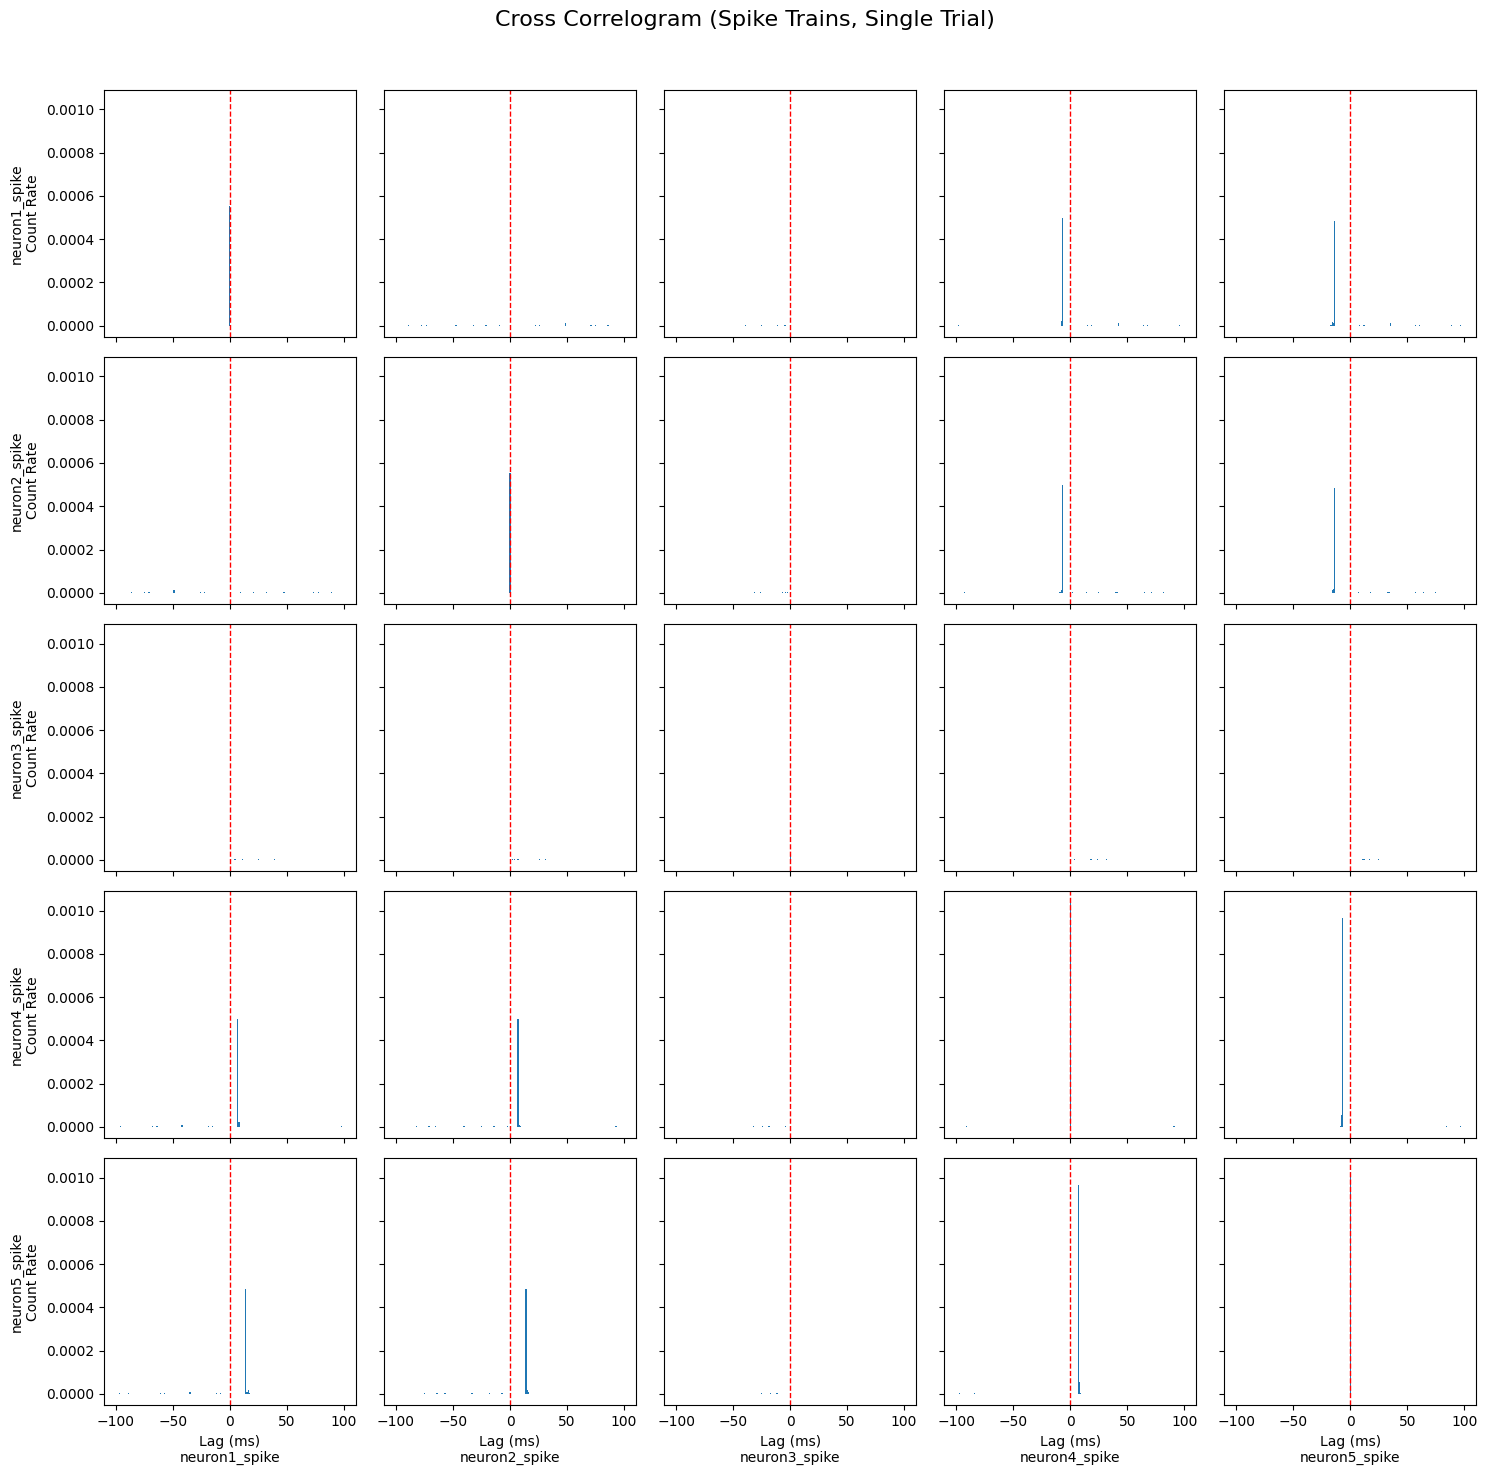

Cross-correlogram for Trial 2


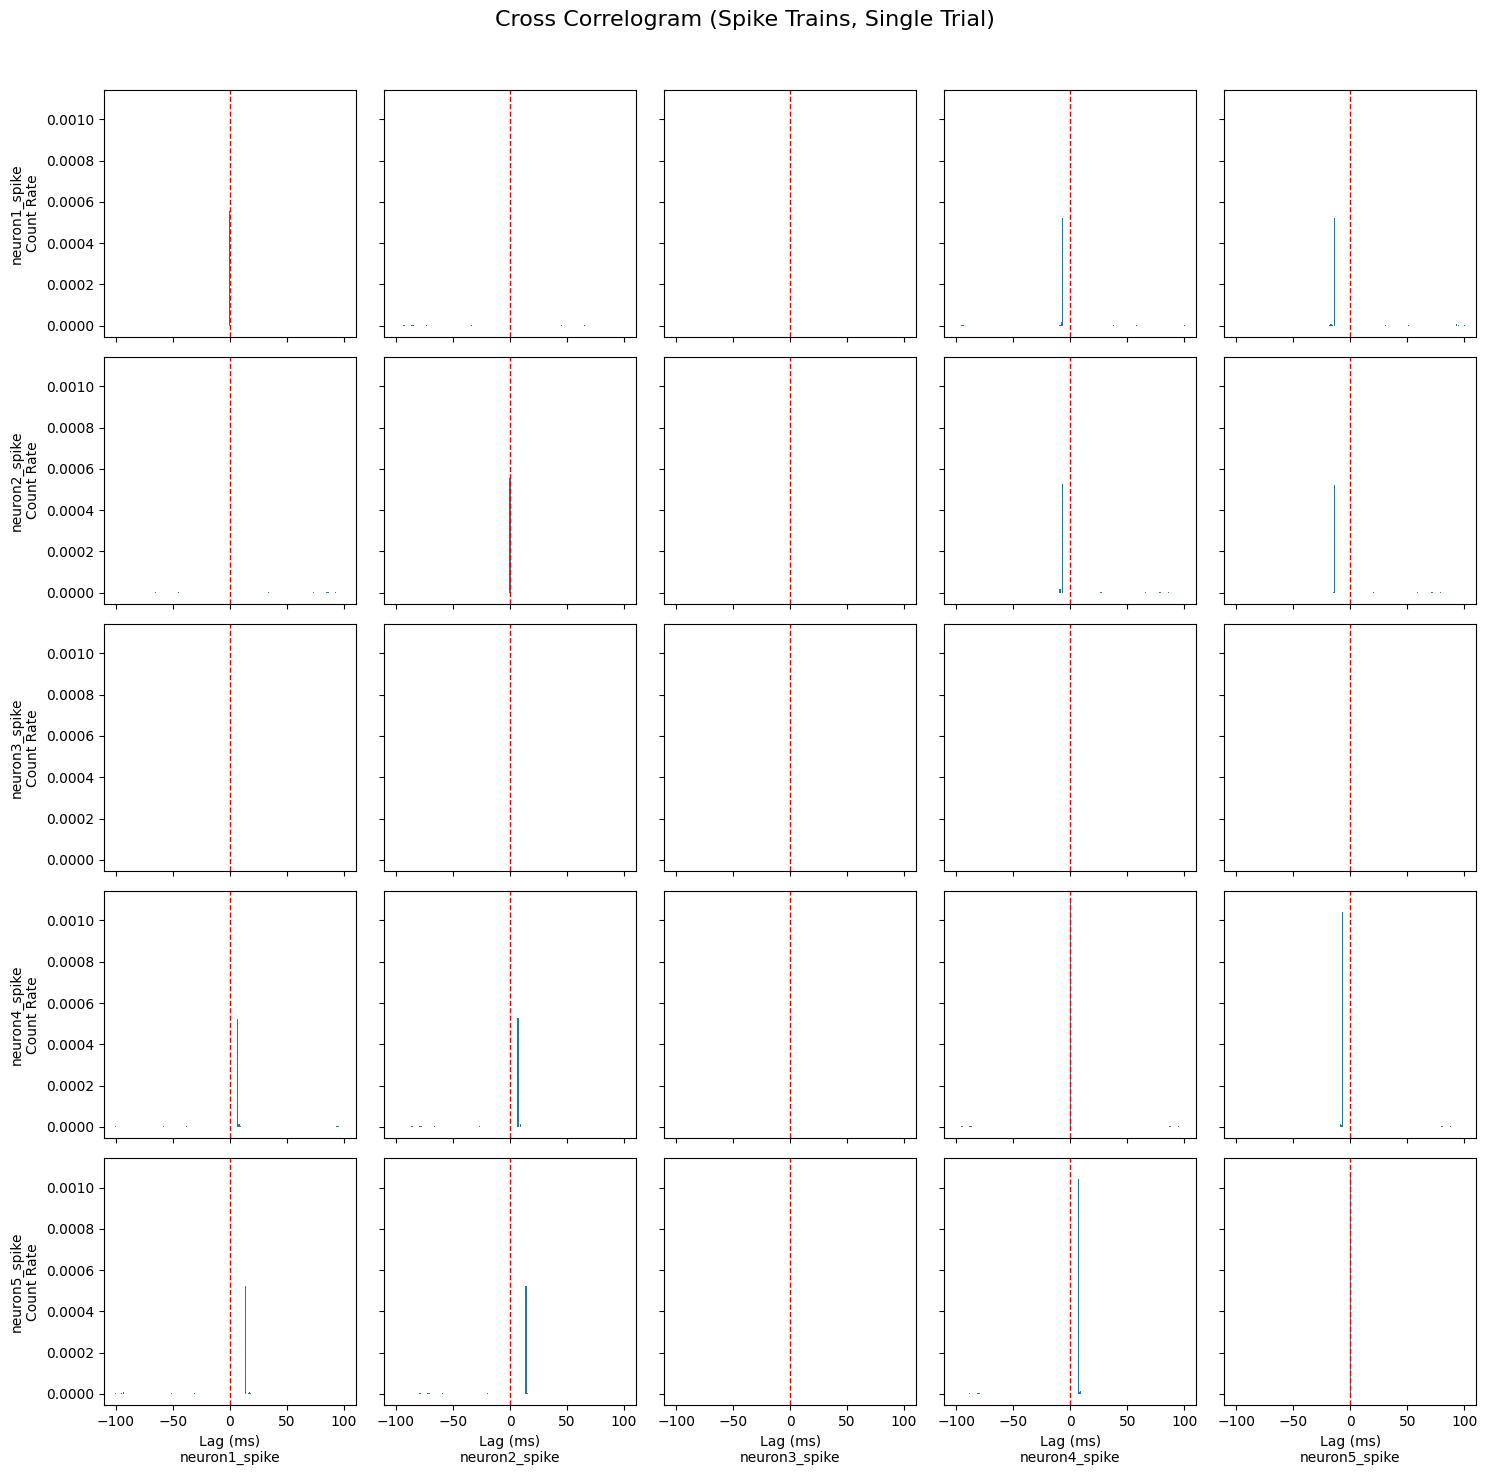

Cross-correlogram for Trial 3


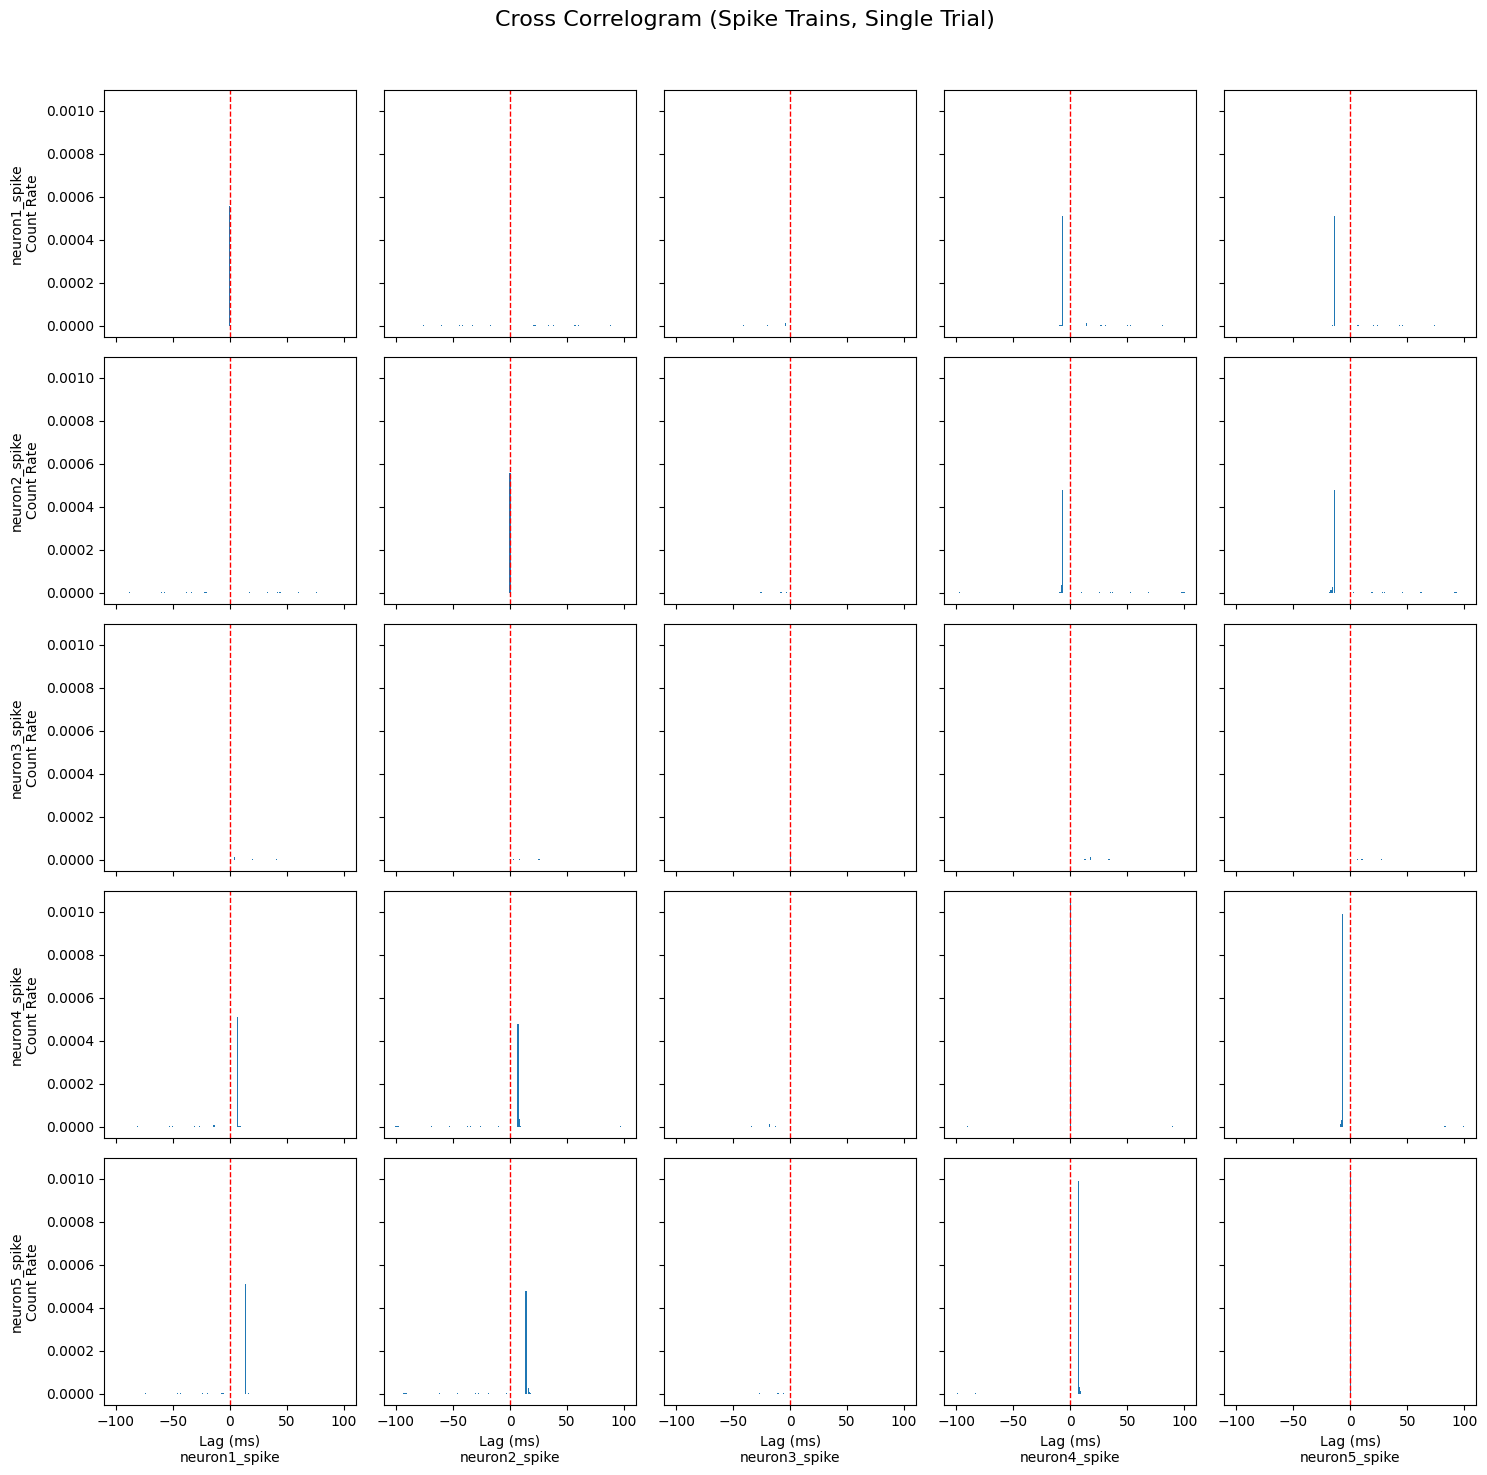

Cross-correlogram for Trial 4


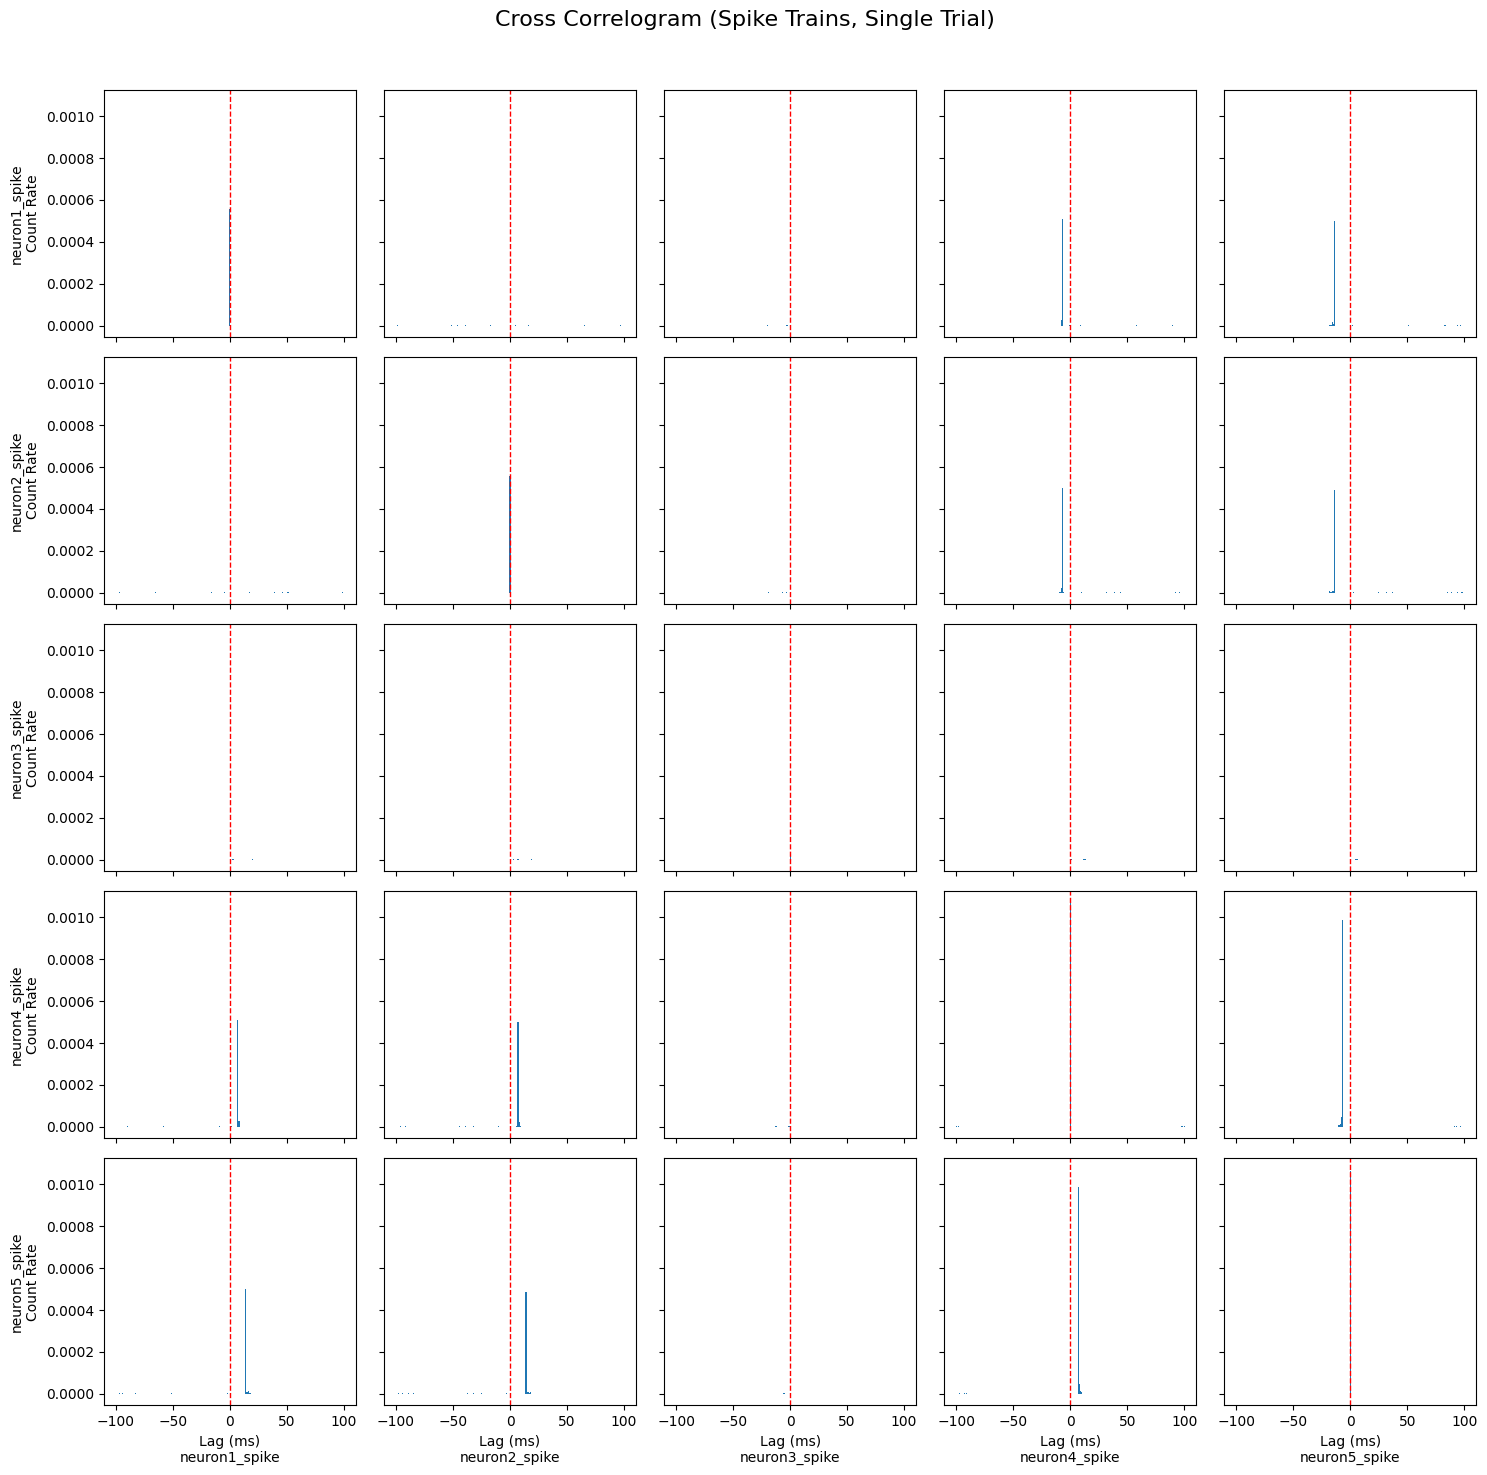

Cross-correlogram for Trial 5


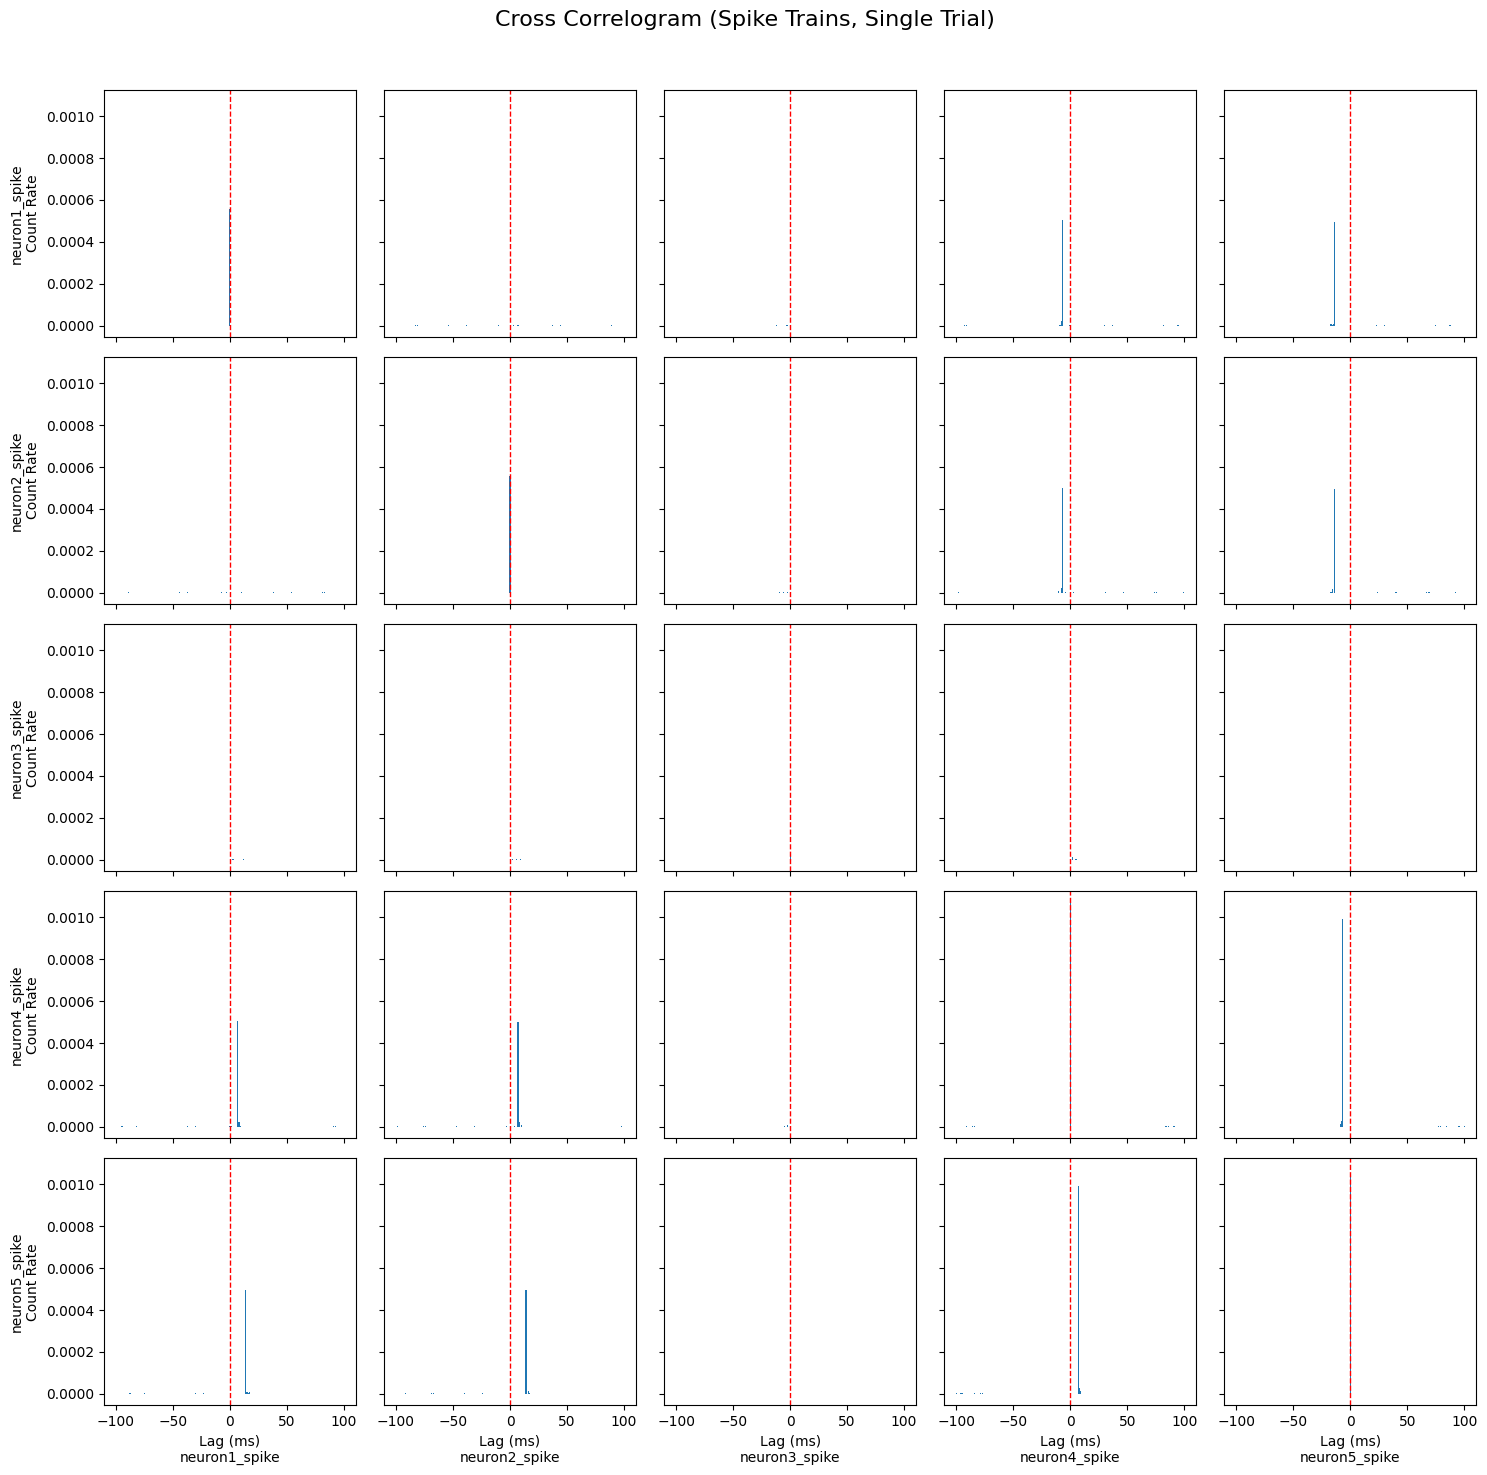

Cross-correlogram for Trial 6


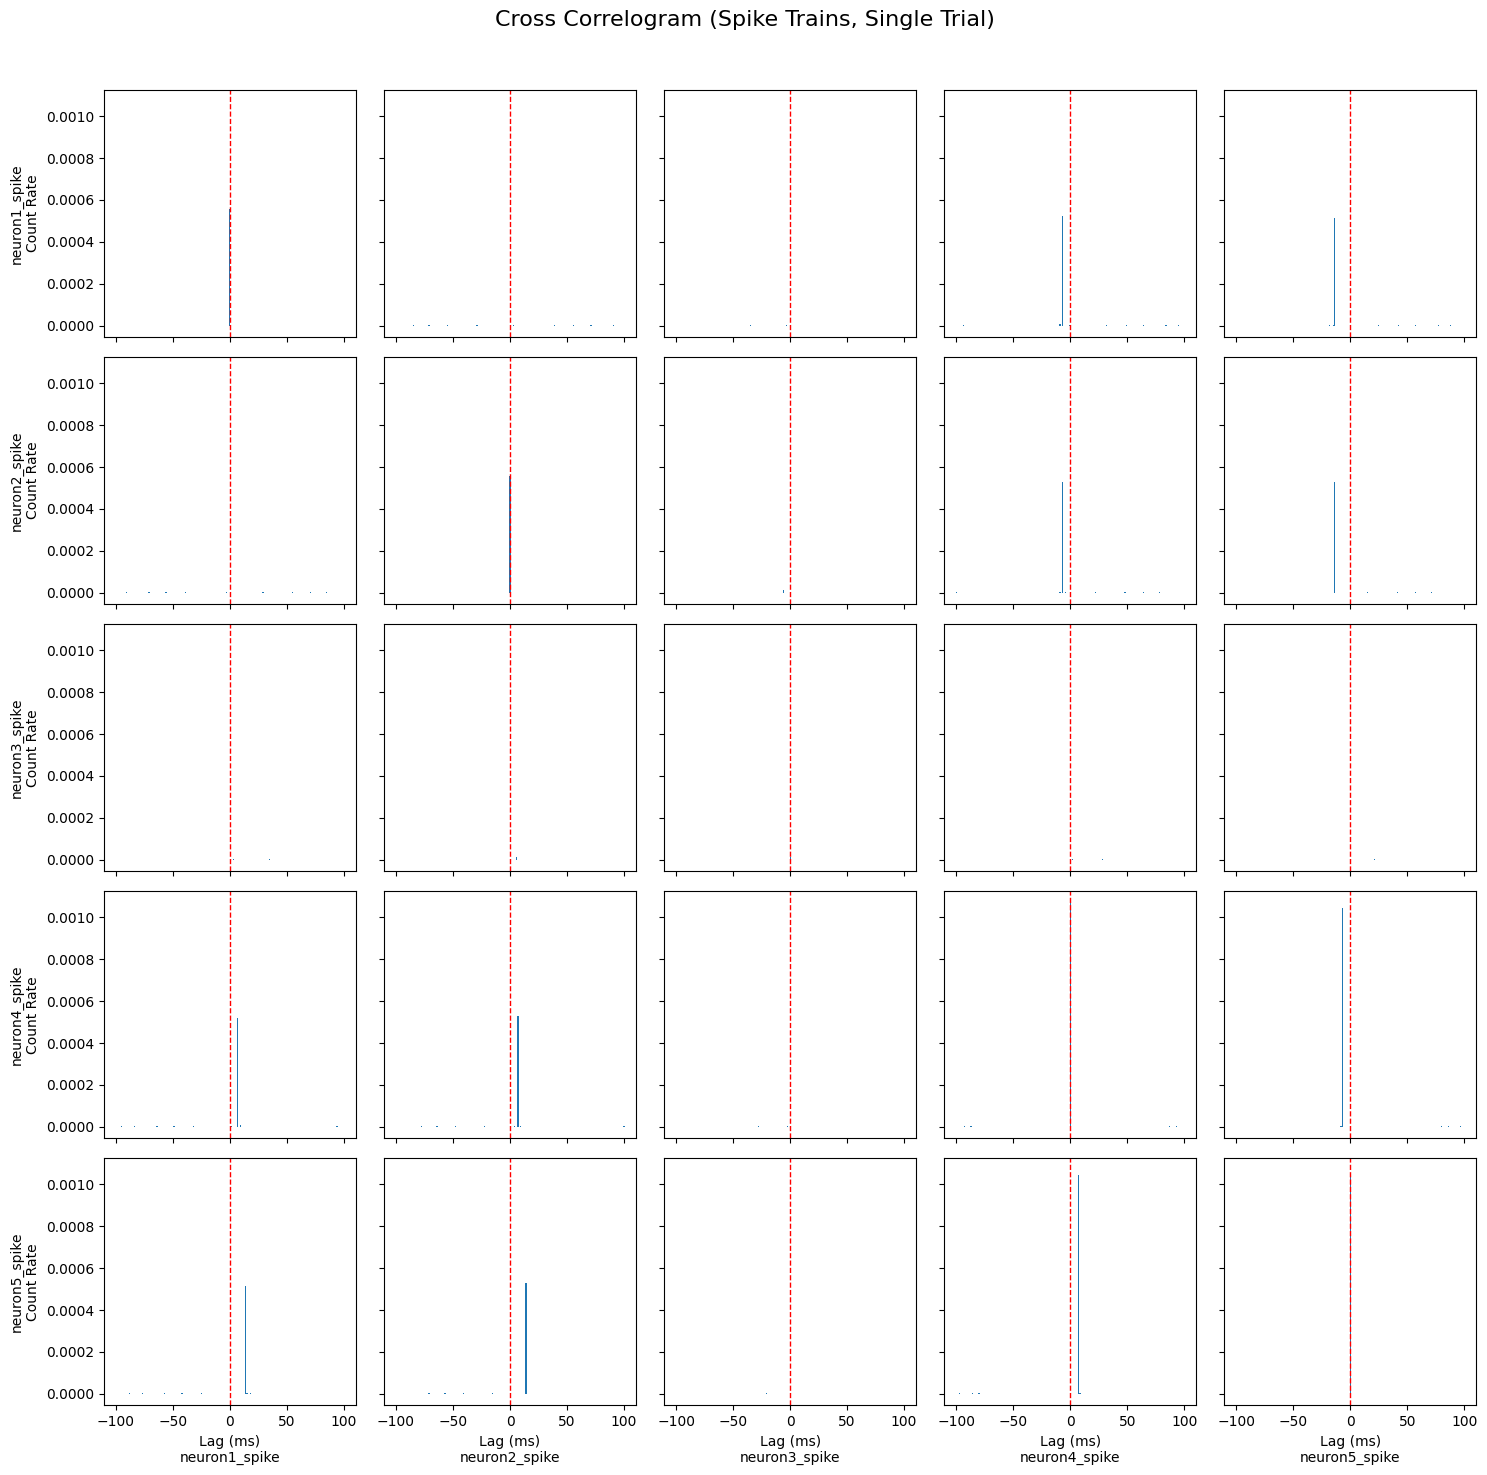

Cross-correlogram for Trial 7


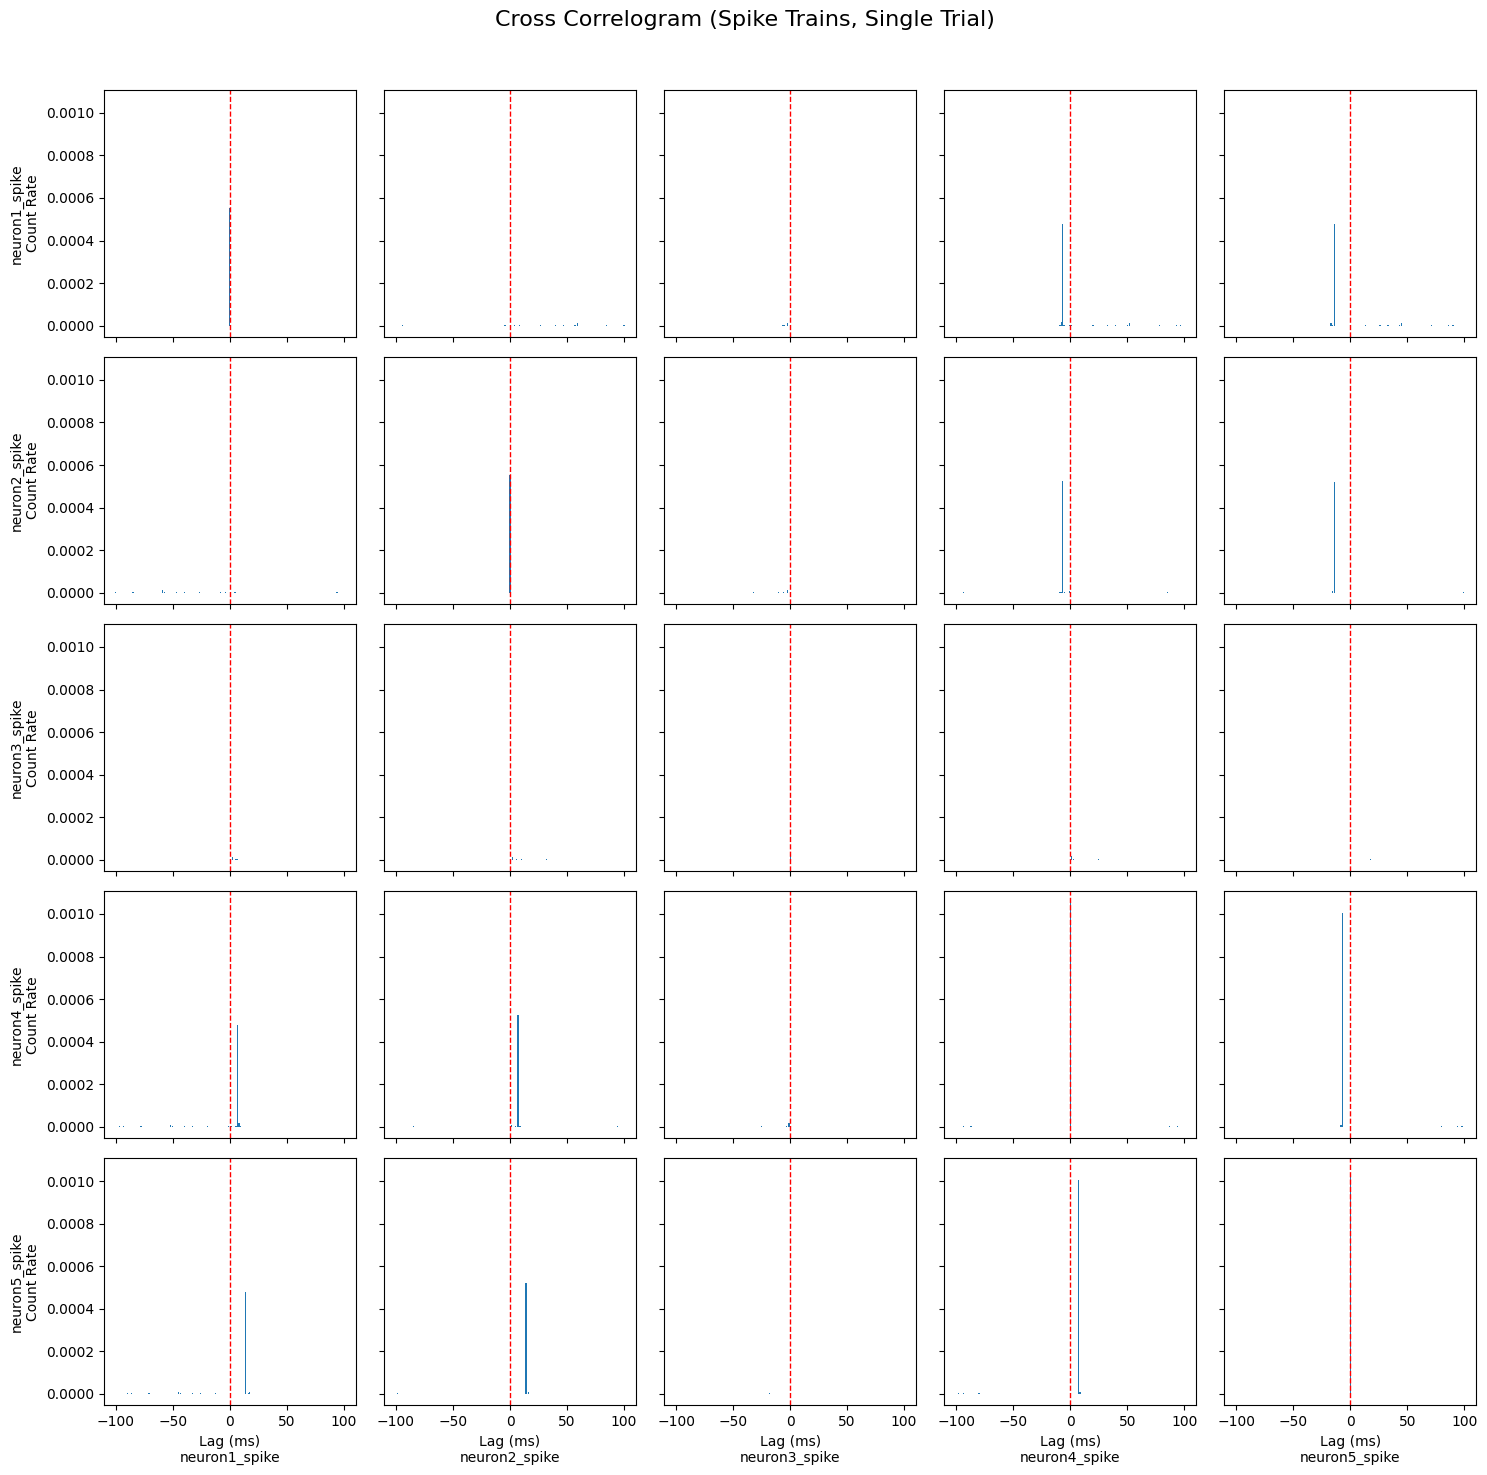

Cross-correlogram for Trial 8


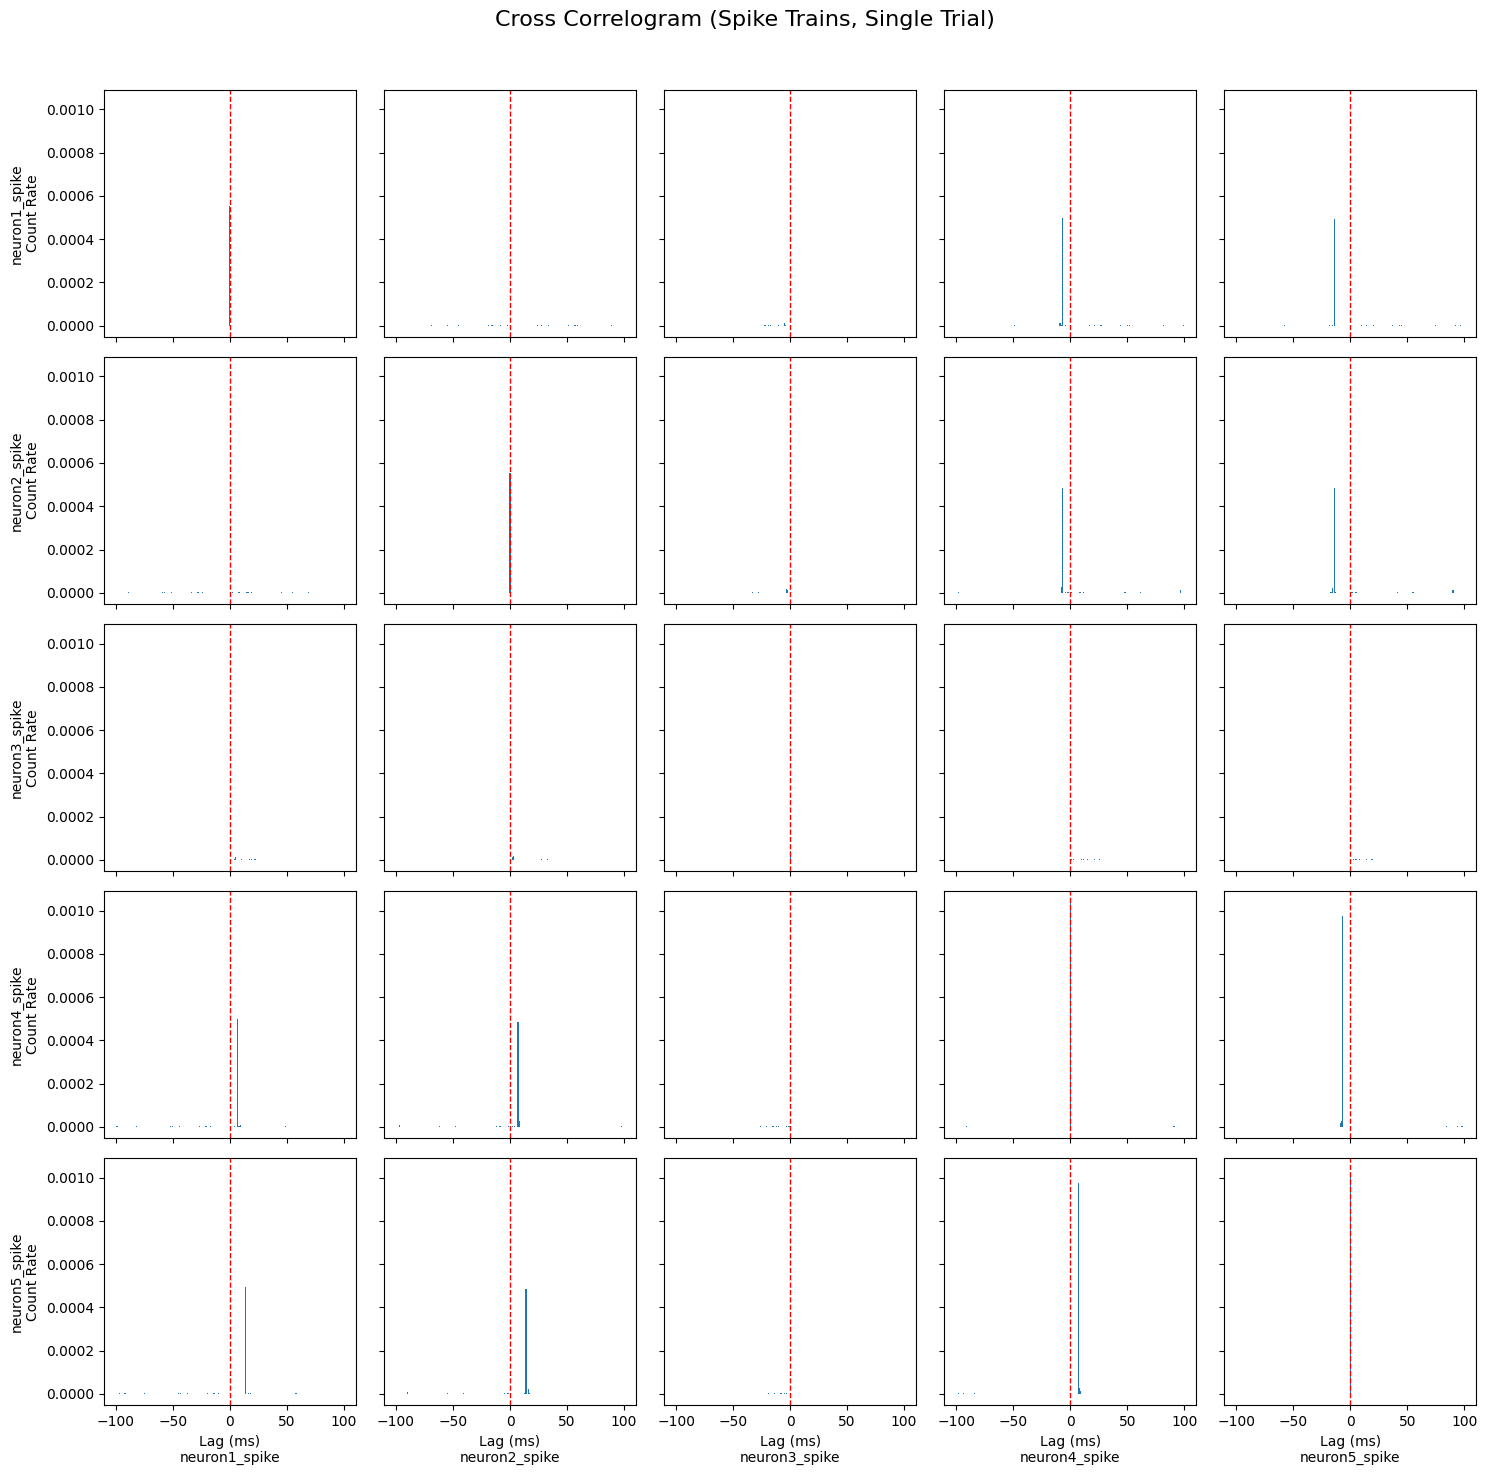

Cross-correlogram for Trial 9


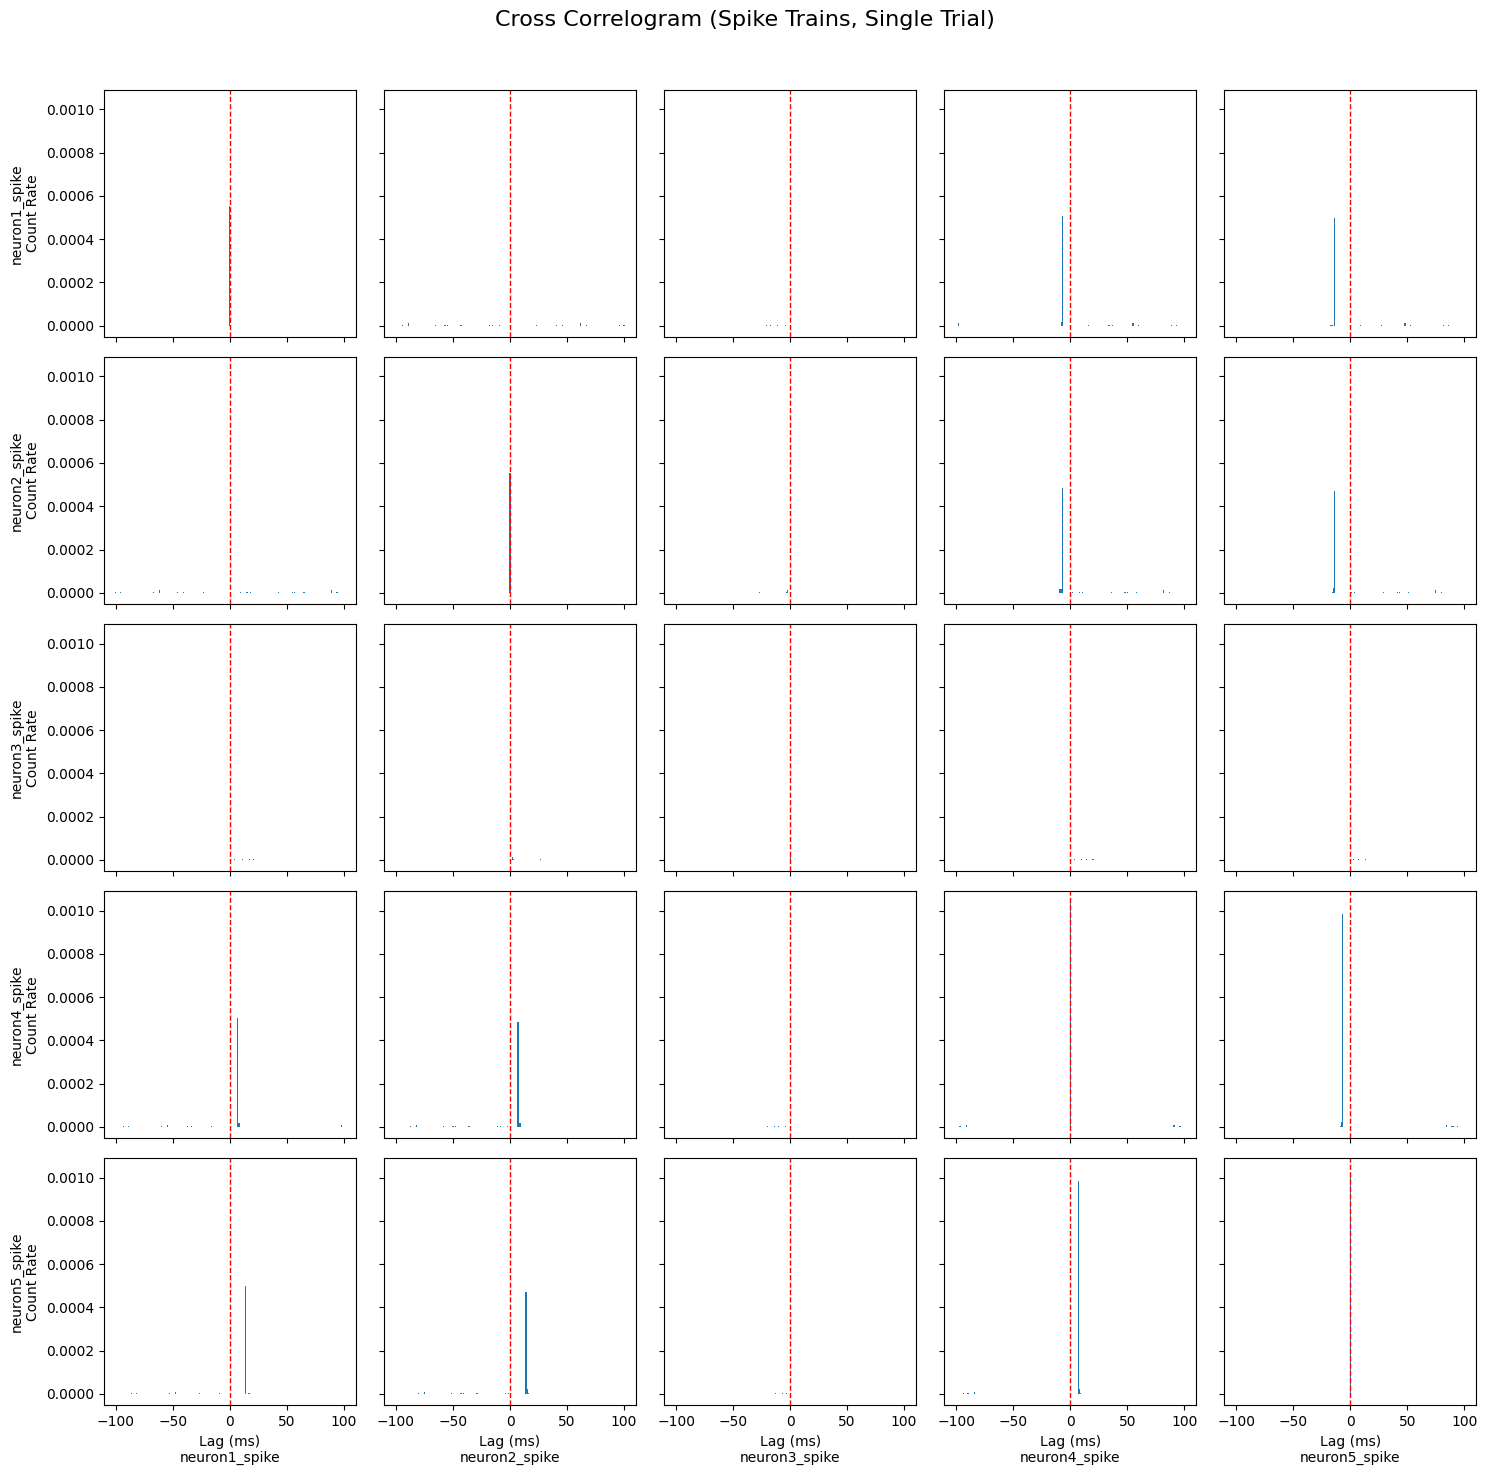

Cross-correlogram for Trial 10


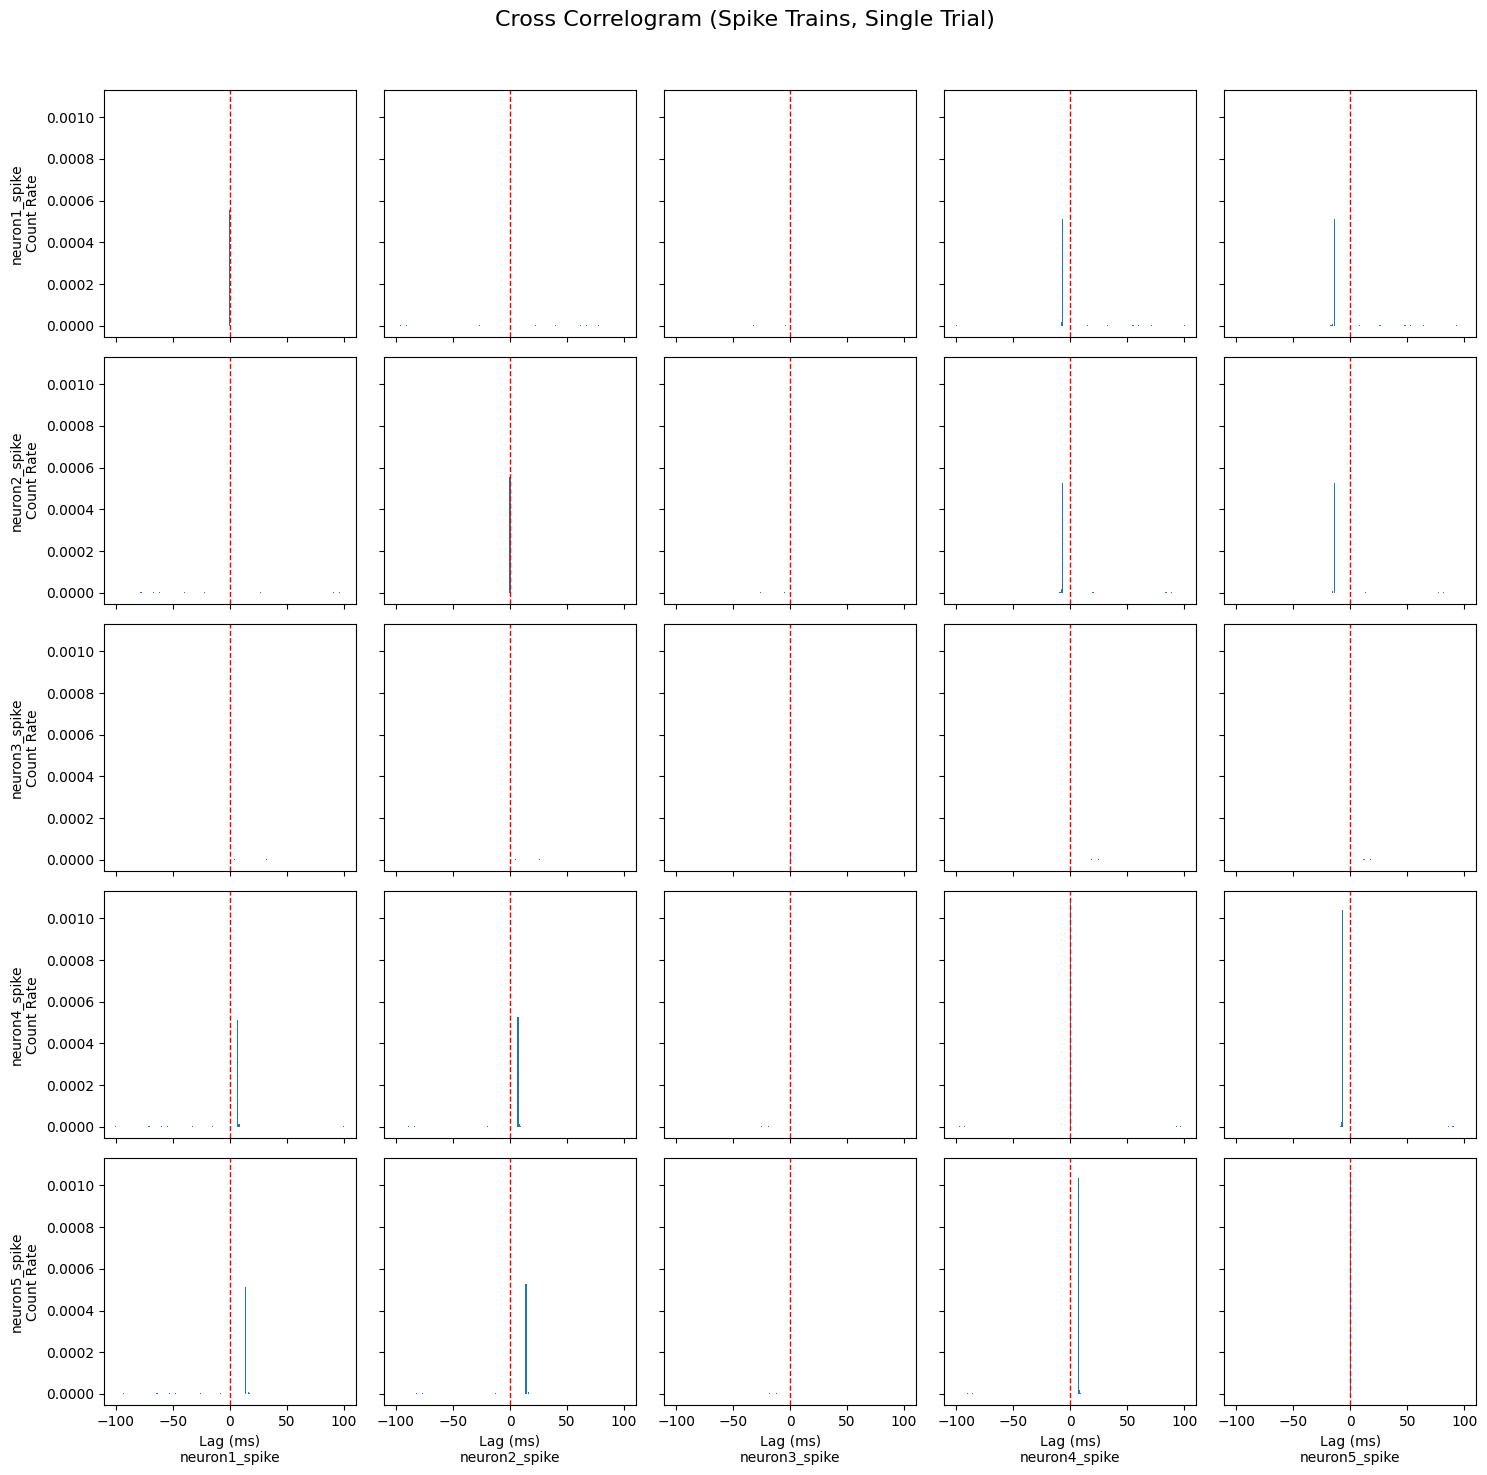

Cross-correlogram for Trial 11


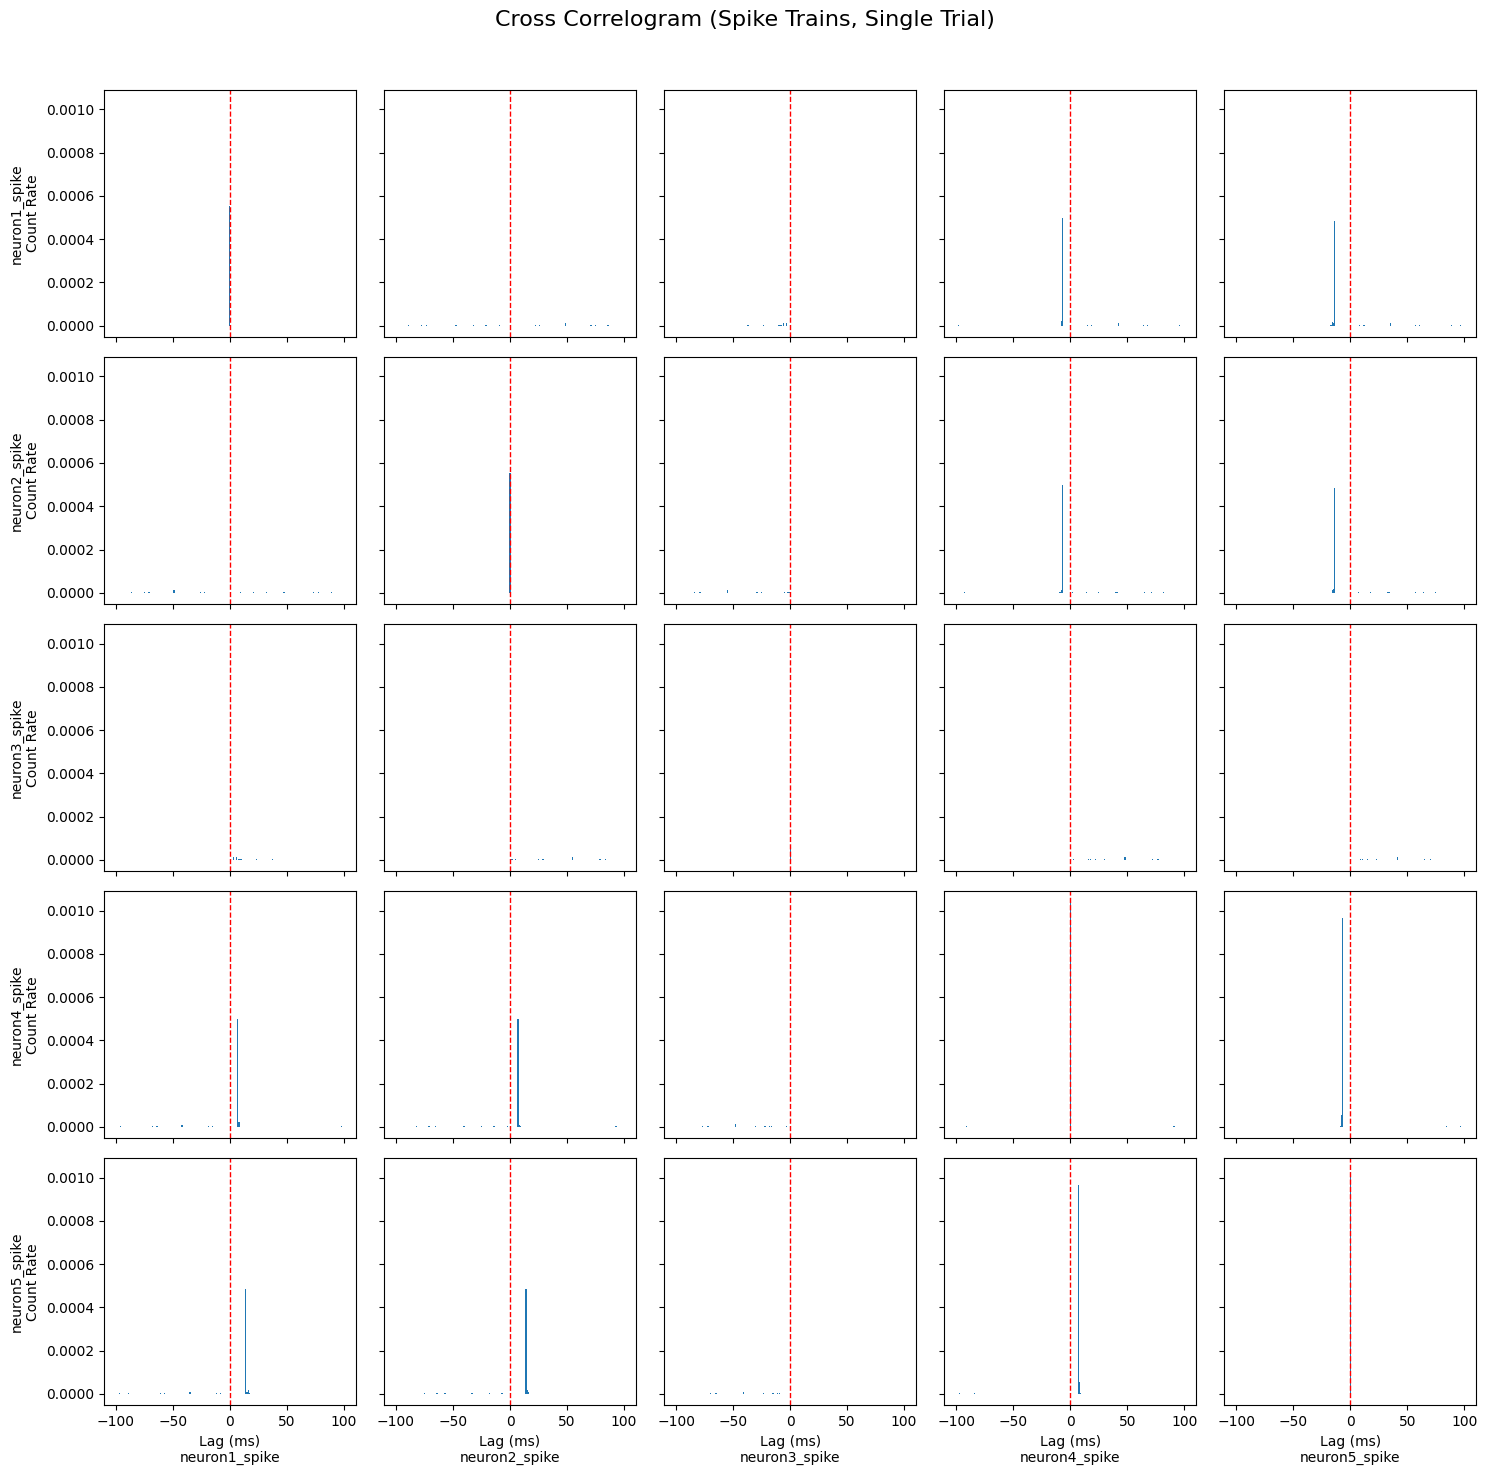

Cross-correlogram for Trial 12


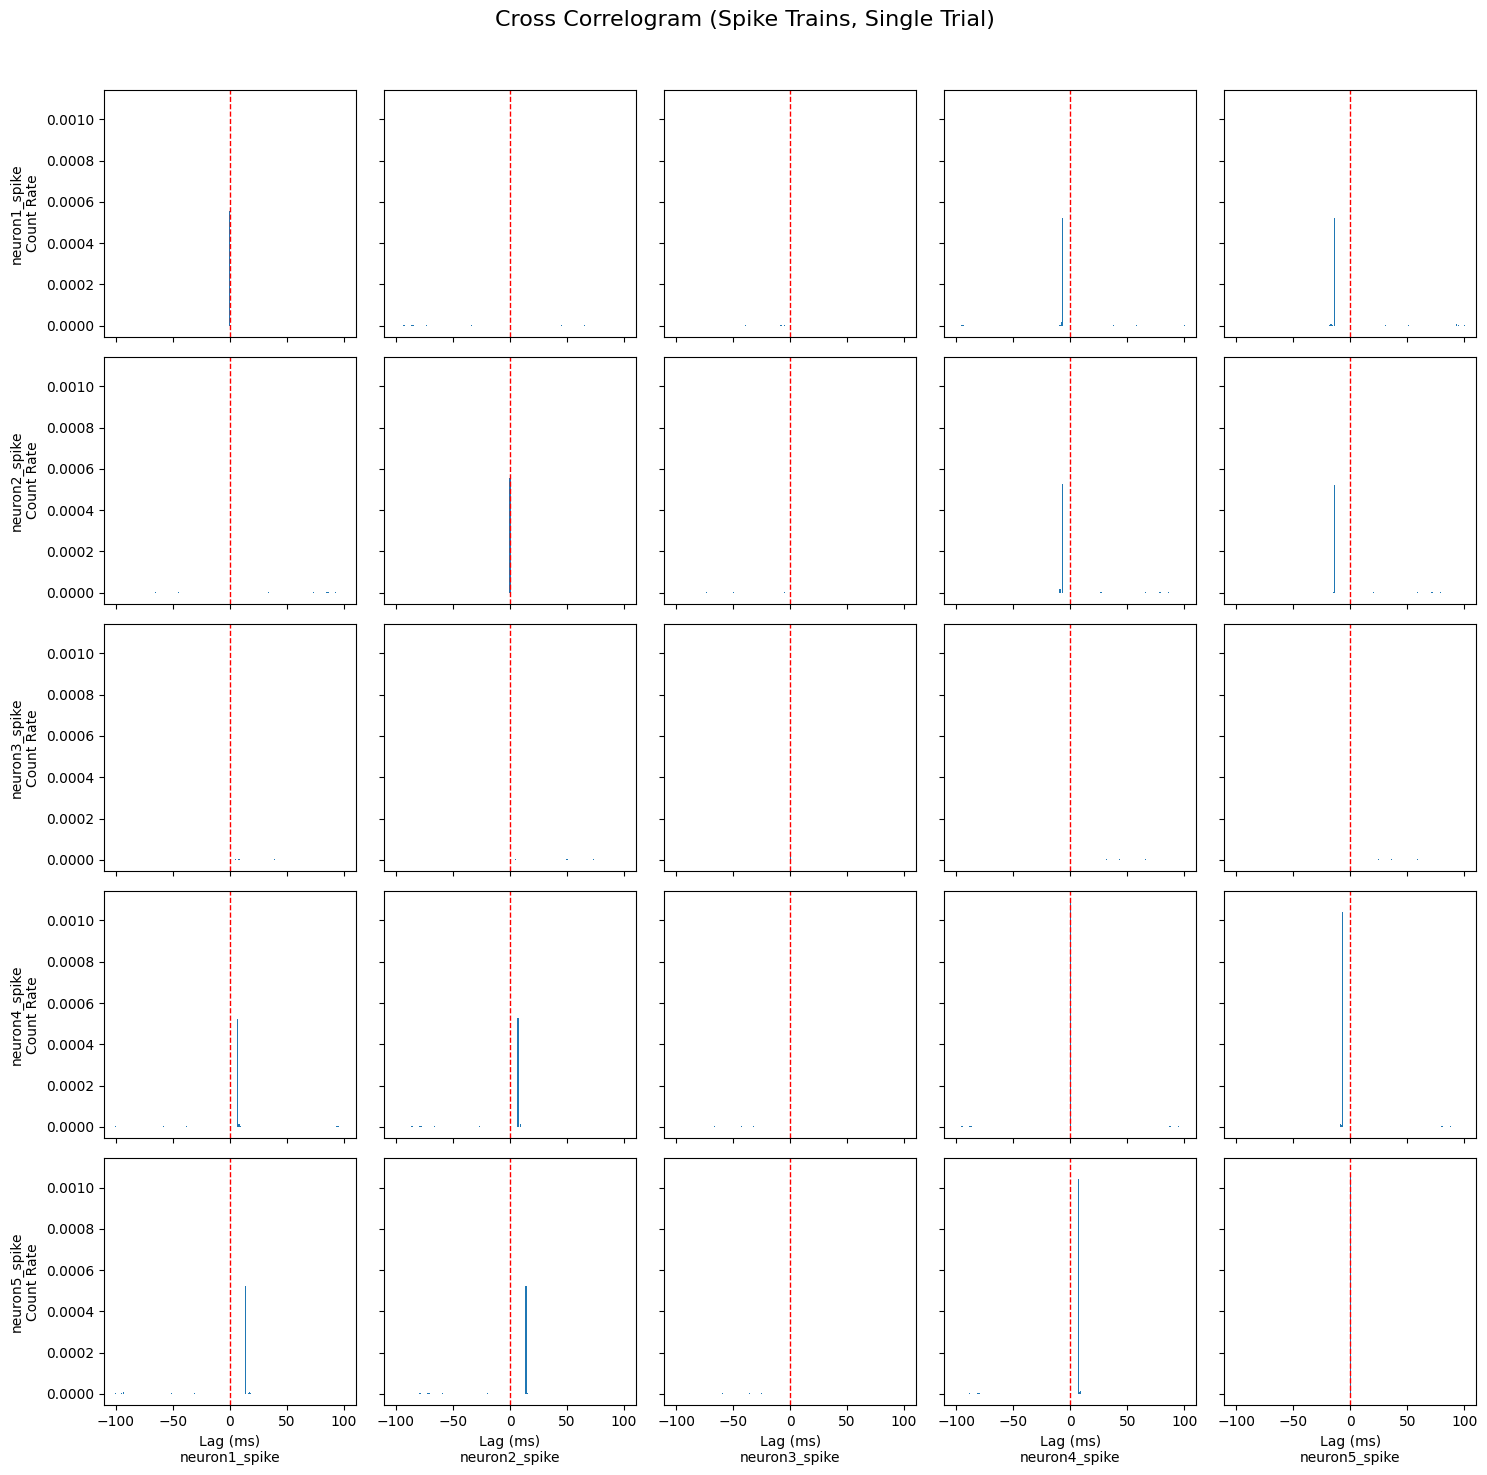

Cross-correlogram for Trial 13


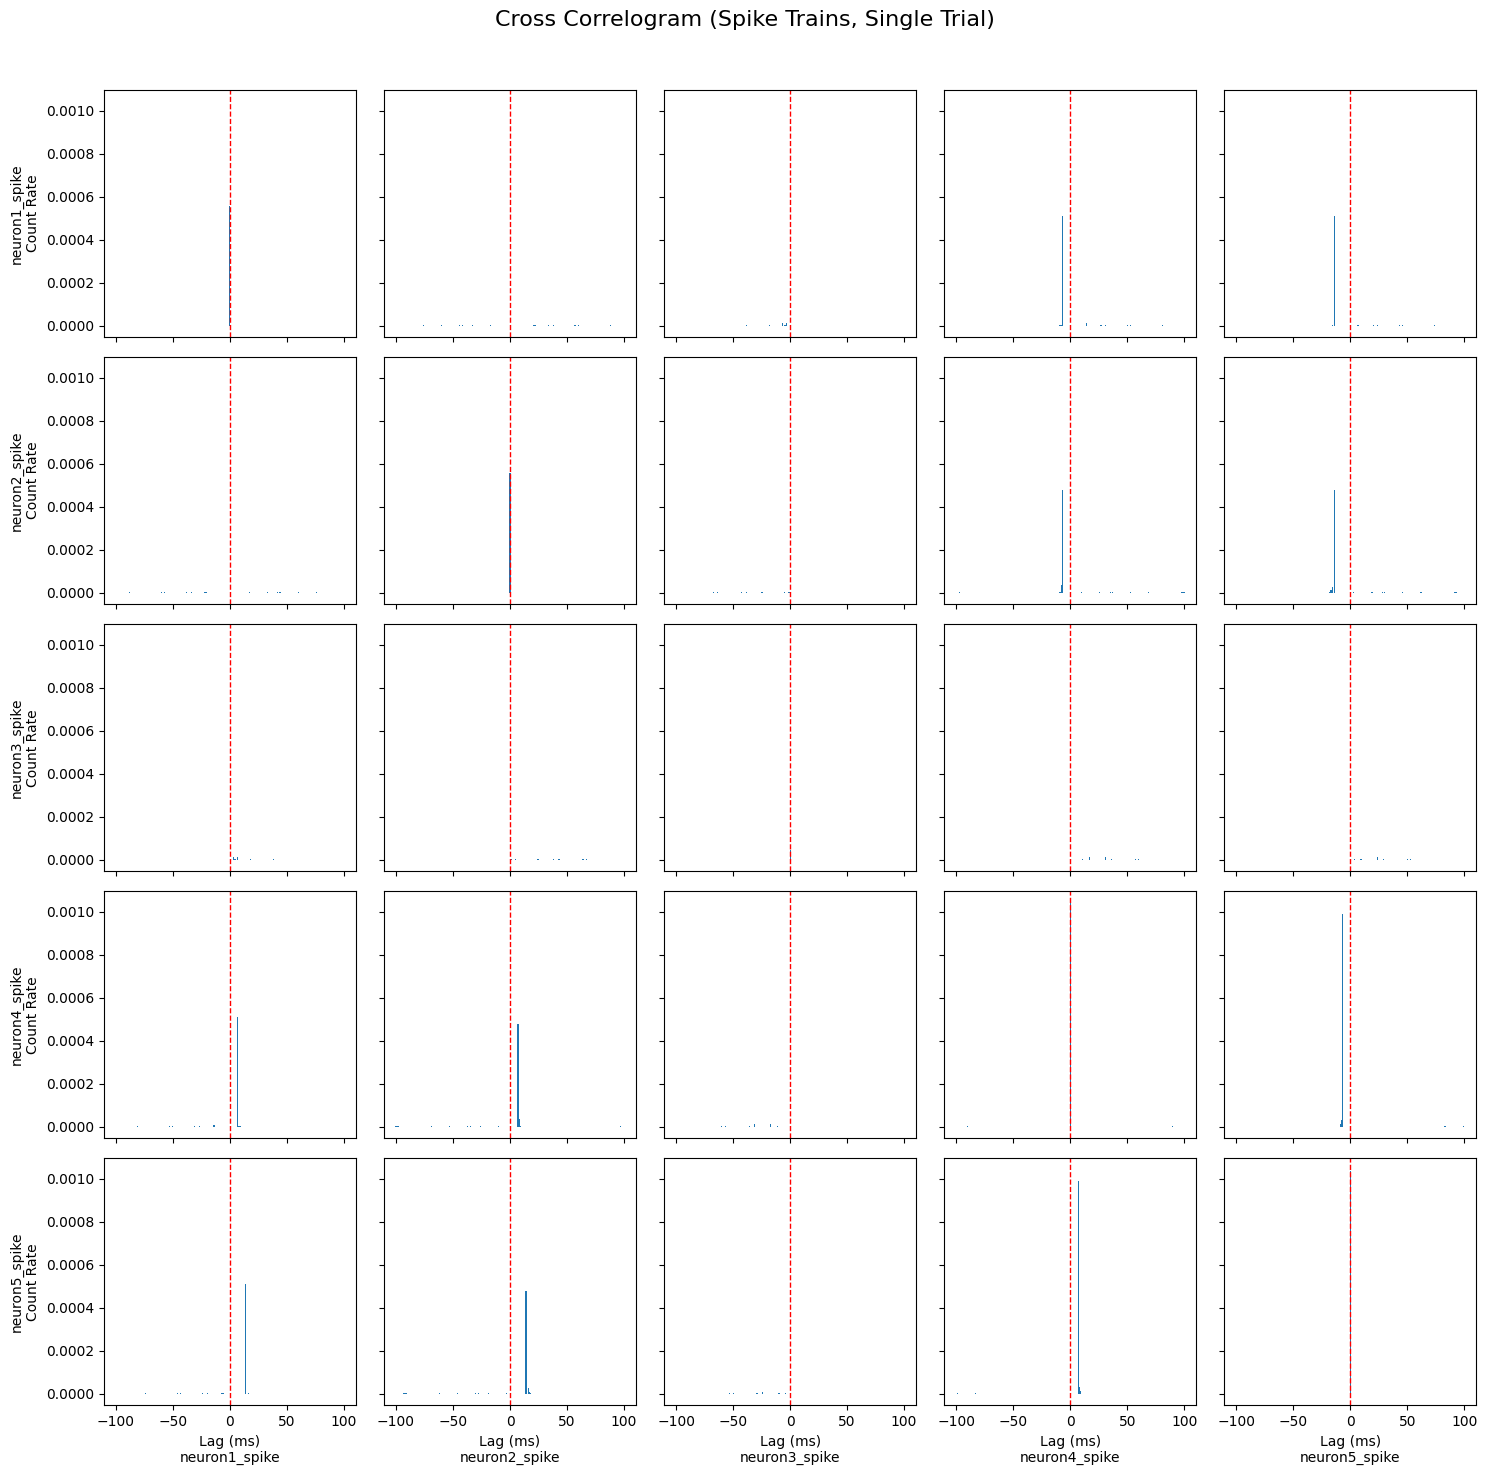

Cross-correlogram for Trial 14


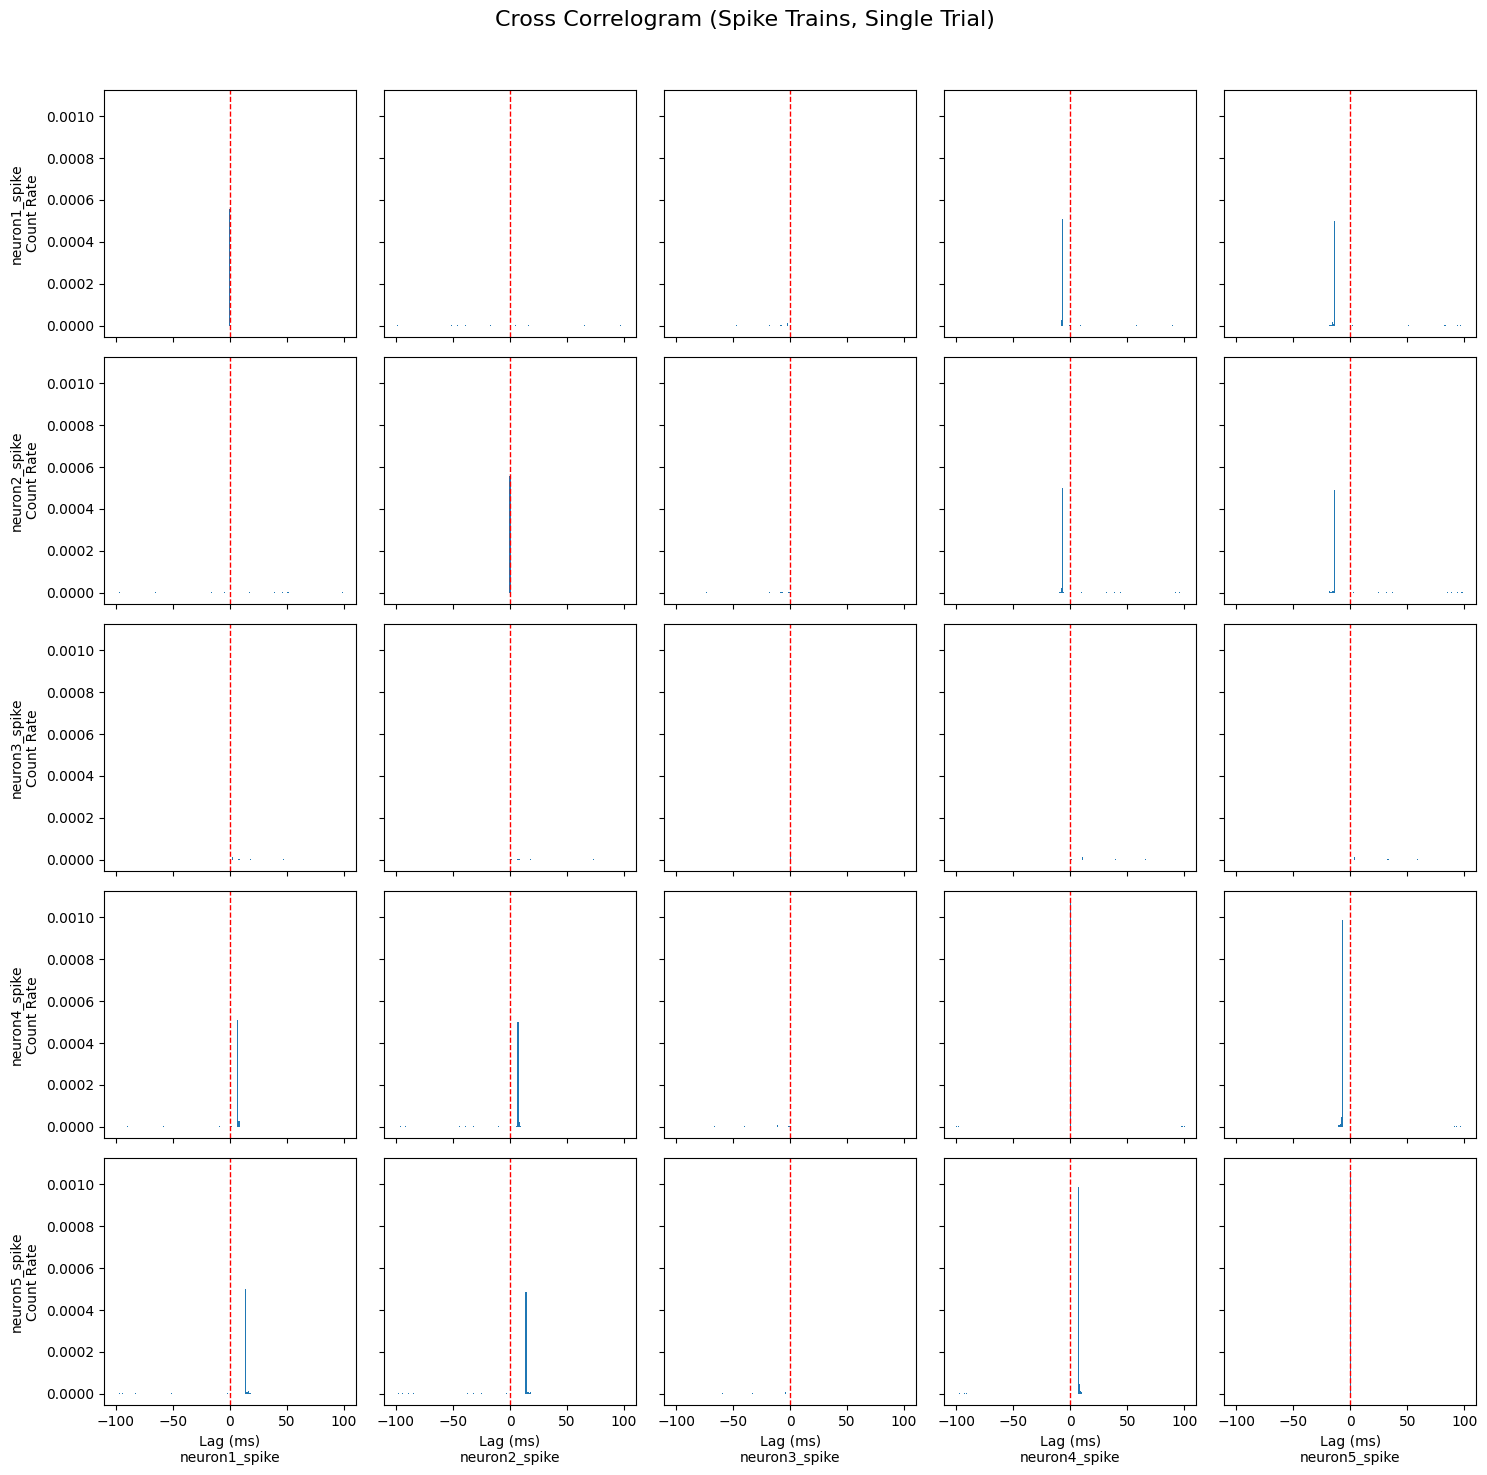

Cross-correlogram for Trial 15


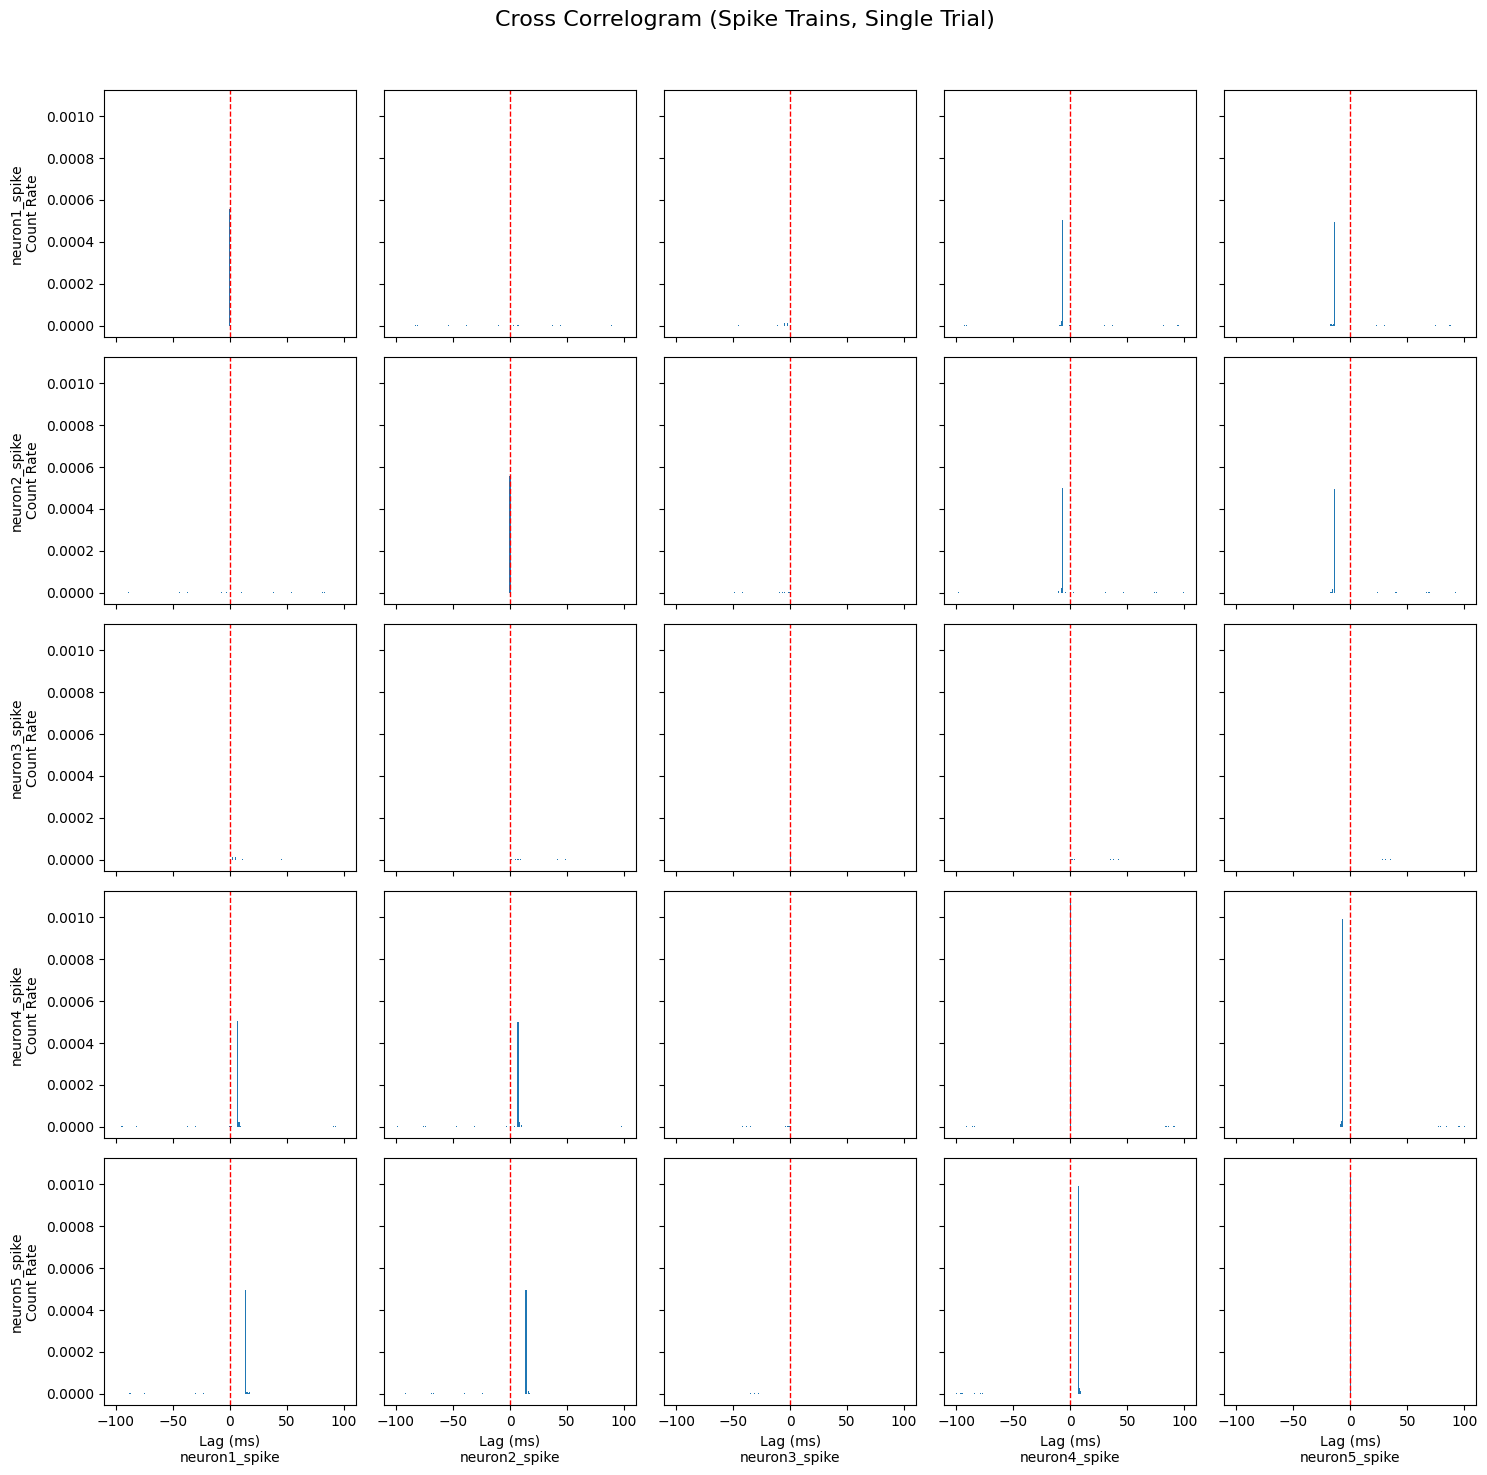

Cross-correlogram for Trial 16


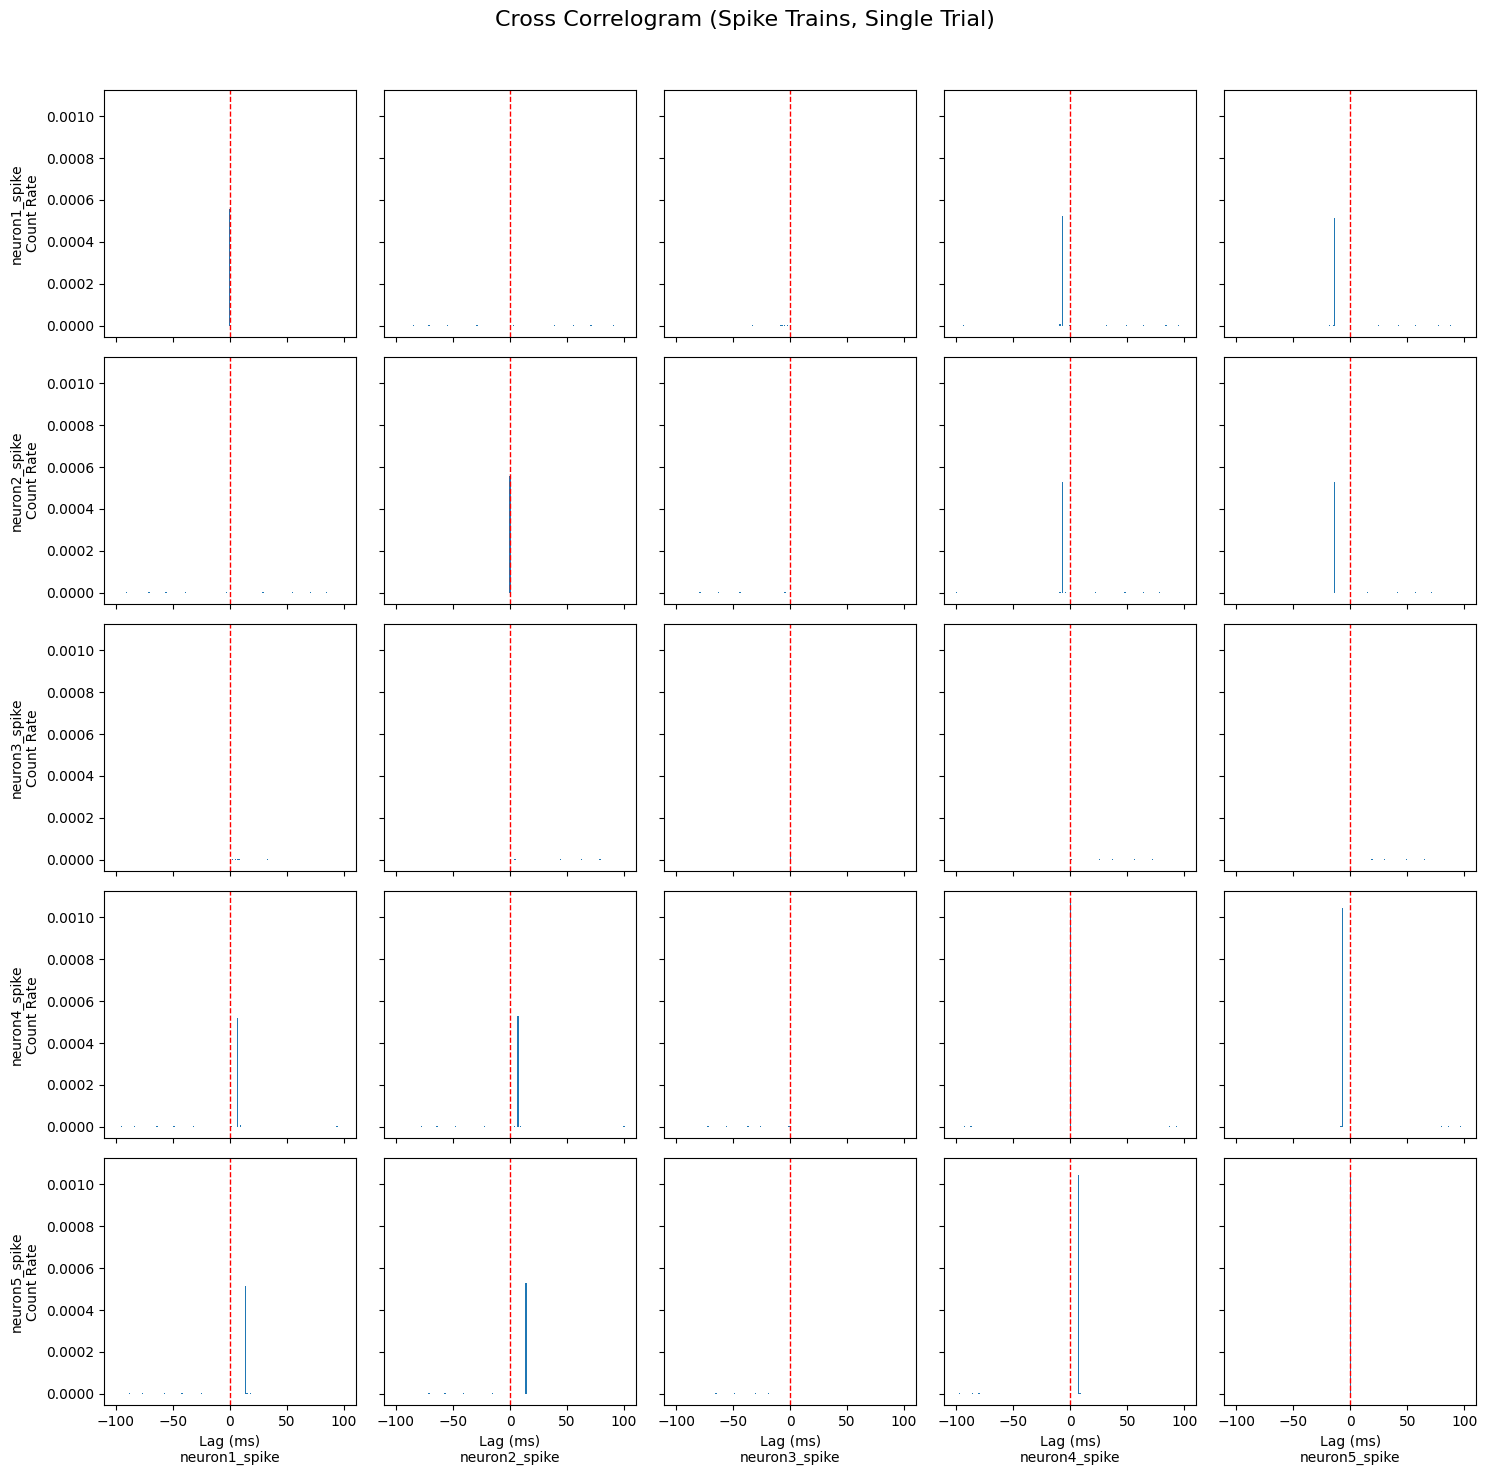

Cross-correlogram for Trial 17


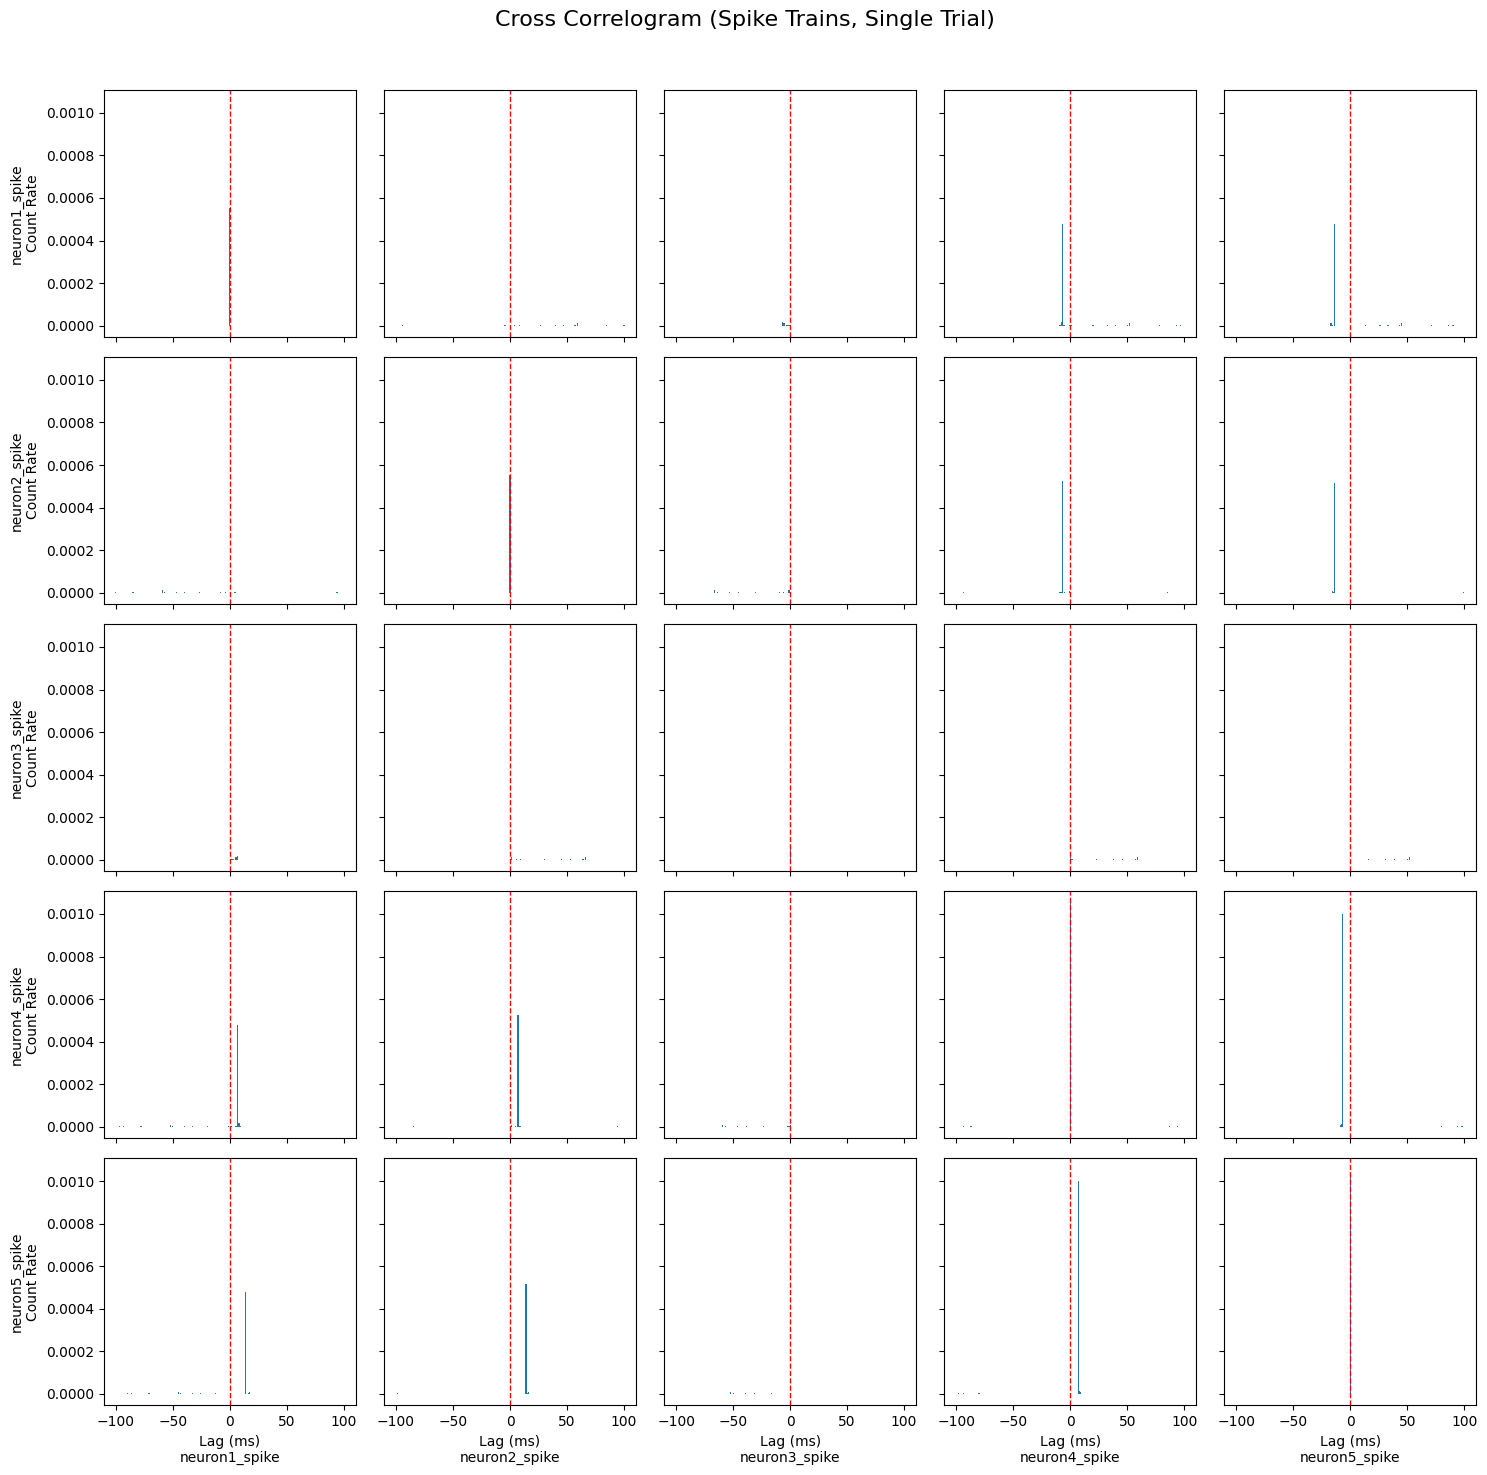

Cross-correlogram for Trial 18


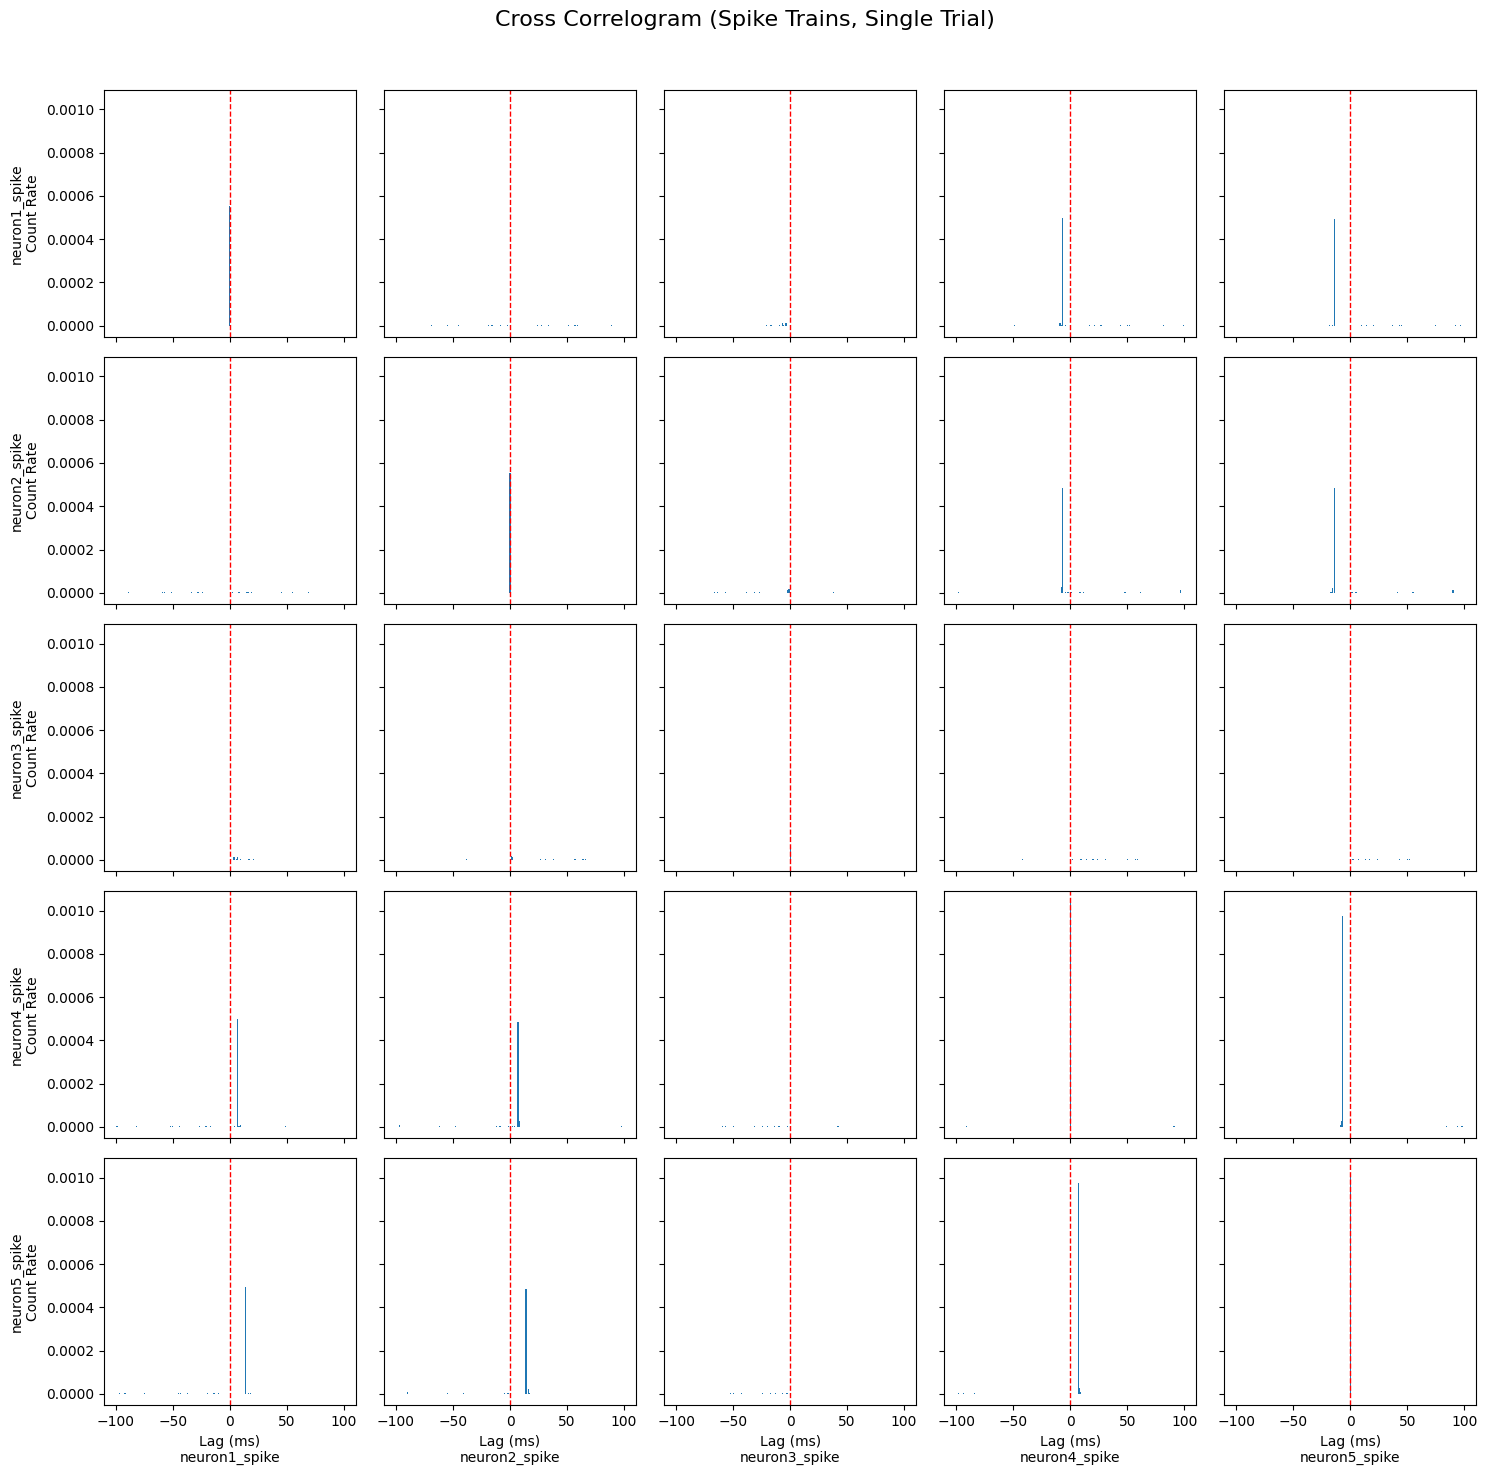

Cross-correlogram for Trial 19


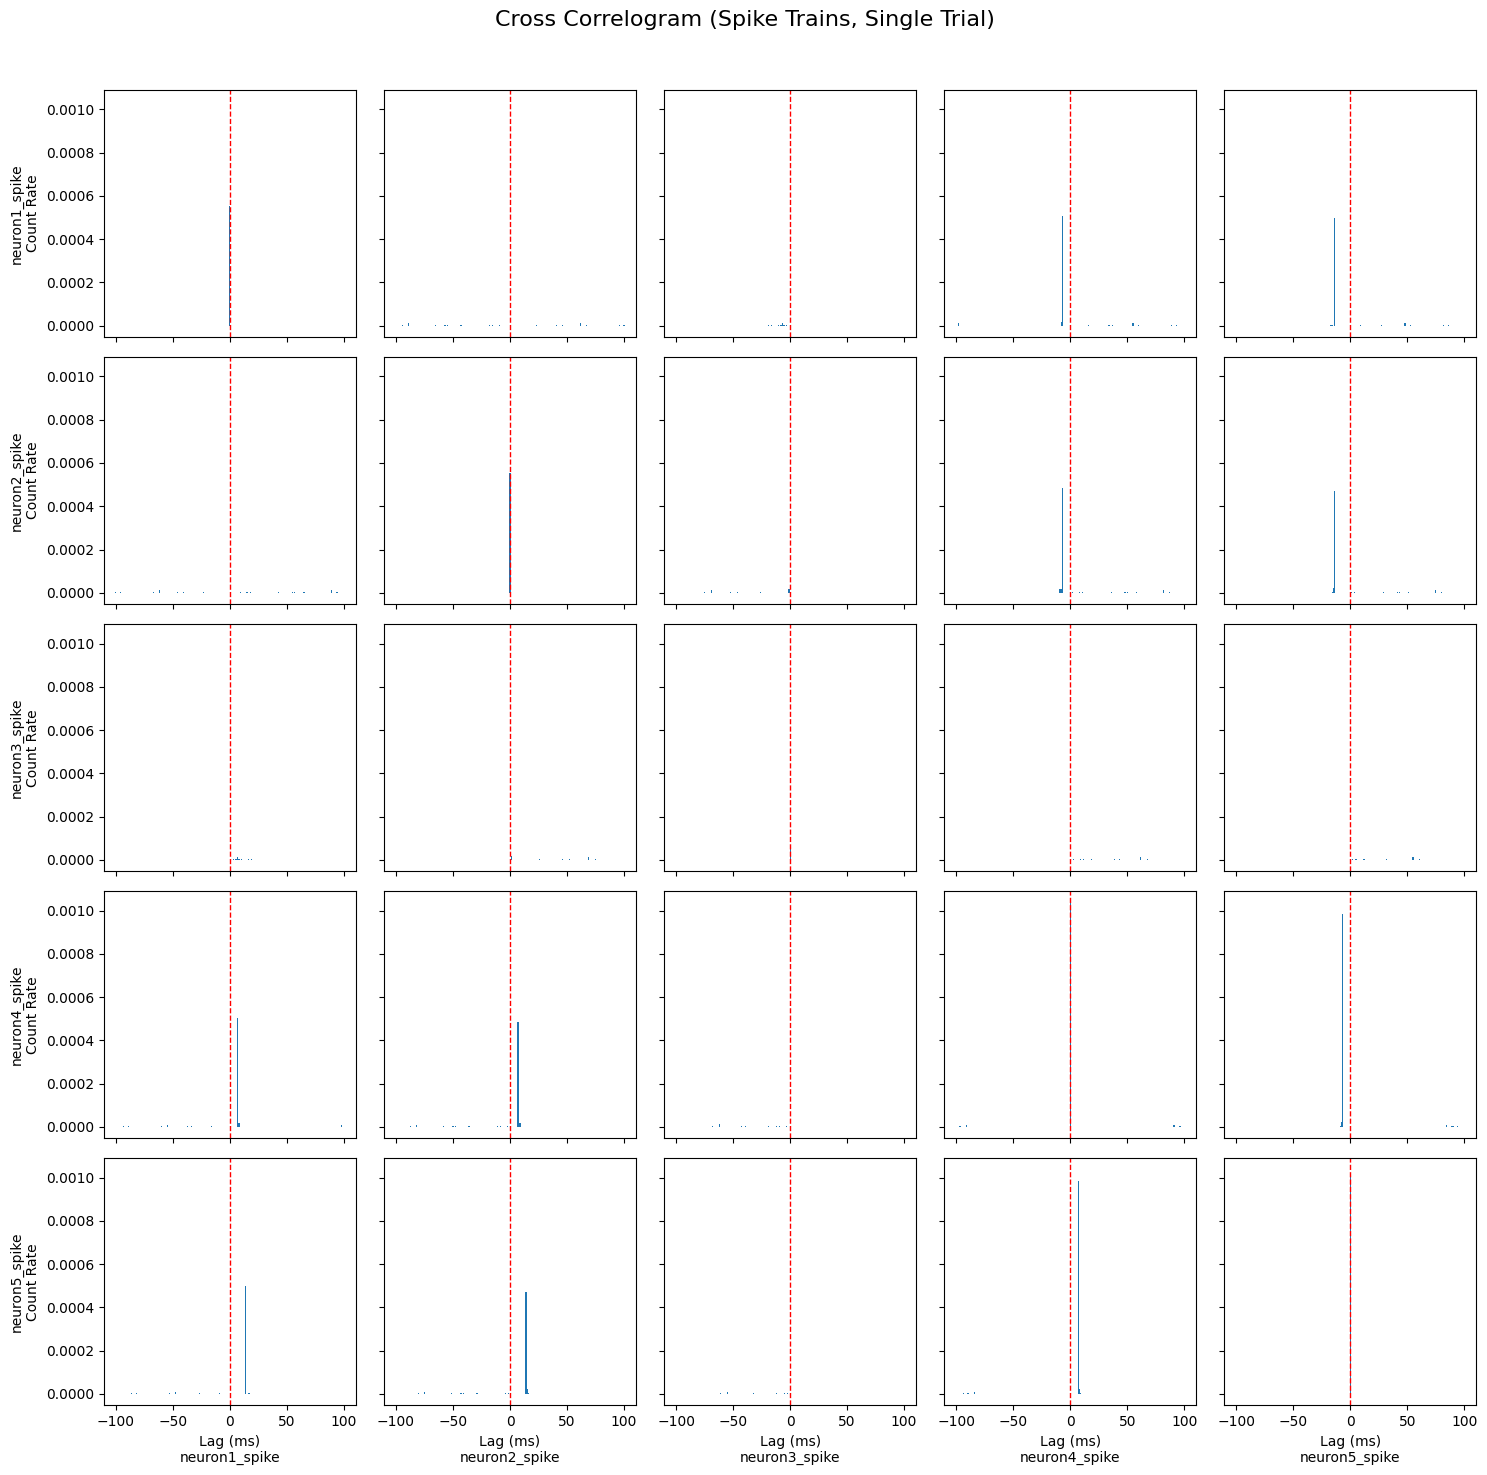

Cross-correlogram for Trial 20


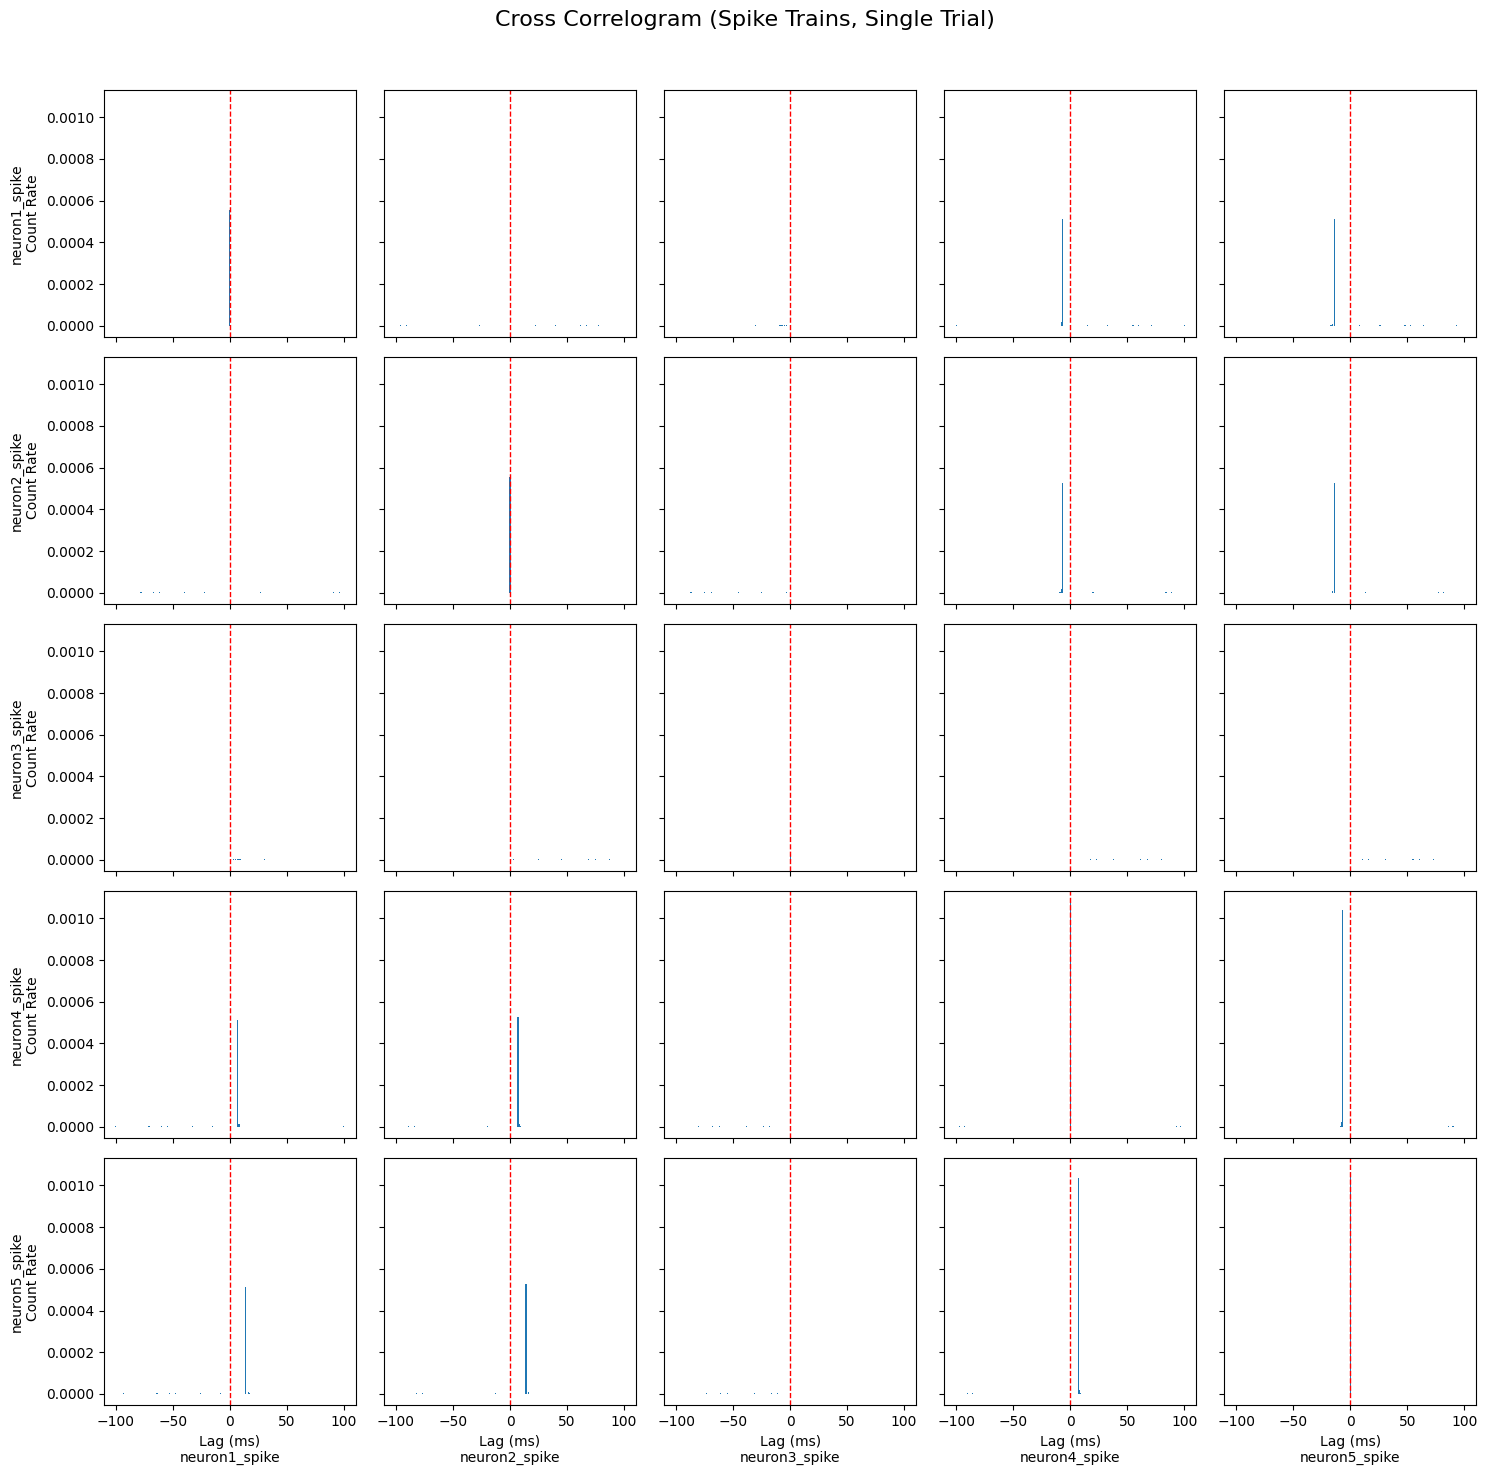

In [106]:
def plot_cross_correlogram(trial_df, spike_columns, max_lag=100, bin_size=1):
    num_neurons = len(spike_columns)
    fig, axes = plt.subplots(num_neurons, num_neurons, figsize=(3*num_neurons, 3*num_neurons), sharex=True, sharey=True)
    lags = np.arange(-max_lag, max_lag+1, bin_size)
    for i, col_i in enumerate(spike_columns):
        spikes_i = trial_df[col_i].values
        for j, col_j in enumerate(spike_columns):
            spikes_j = trial_df[col_j].values
            corr = np.correlate(spikes_i - np.mean(spikes_i), spikes_j - np.mean(spikes_j), mode='full')
            center = len(corr) // 2
            corr_lags = corr[center-max_lag:center+max_lag+1]
            corr_rate = corr_lags / trial_df.shape[0]
            ax = axes[i, j] if num_neurons > 1 else axes
            ax.bar(lags, corr_rate, width=1, color='tab:blue')
            if i == num_neurons - 1:
                ax.set_xlabel(f"Lag (ms)\n{col_j}")
            if j == 0:
                ax.set_ylabel(f"{col_i}\nCount Rate")
            ax.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.suptitle("Cross Correlogram (Spike Trains, Single Trial)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

for idx, trial_df in enumerate(all_trials):
    print(f"Cross-correlogram for Trial {idx+1}")
    plot_cross_correlogram(trial_df, spike_columns, max_lag=100, bin_size=1)

Cross-correlogram for Ground Truth (Concatenated)


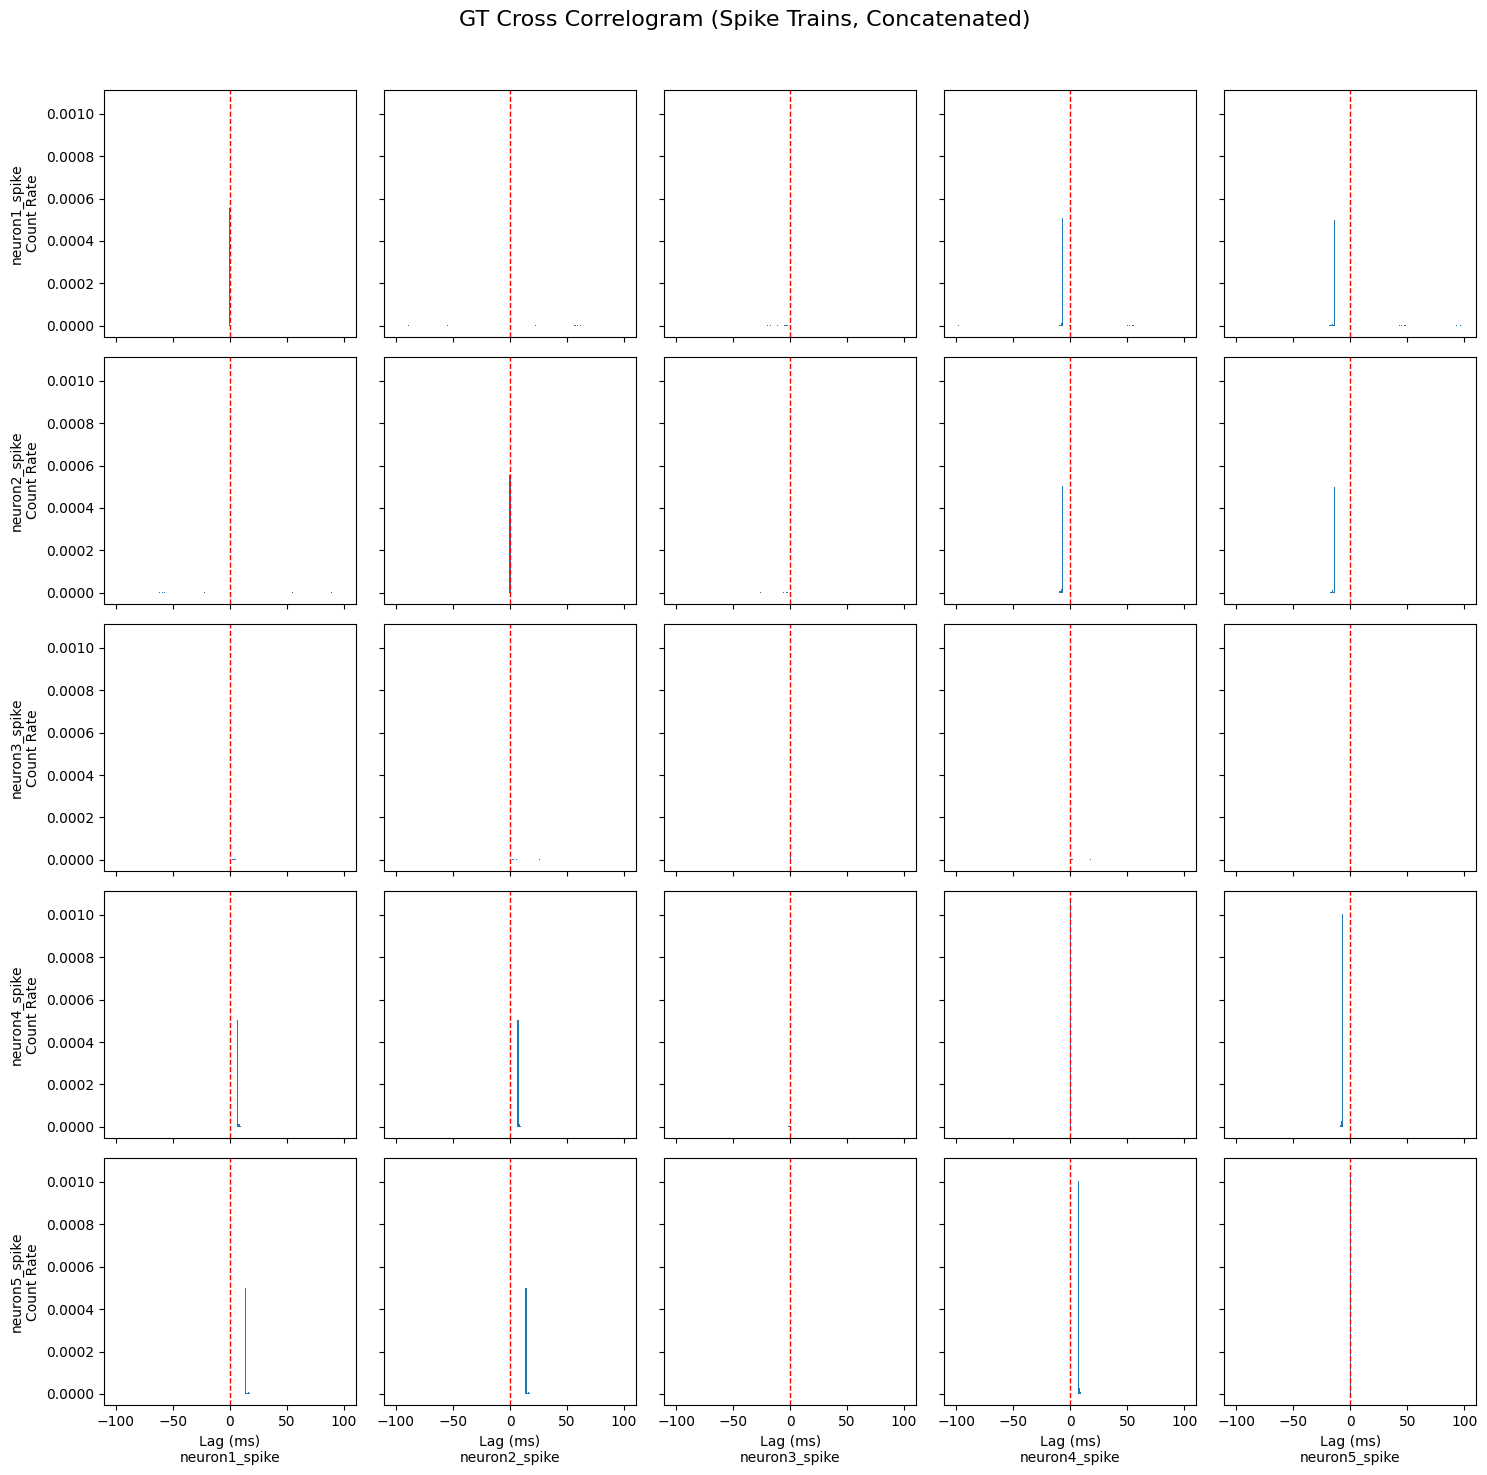

Cross-correlogram for Submission (Concatenated)


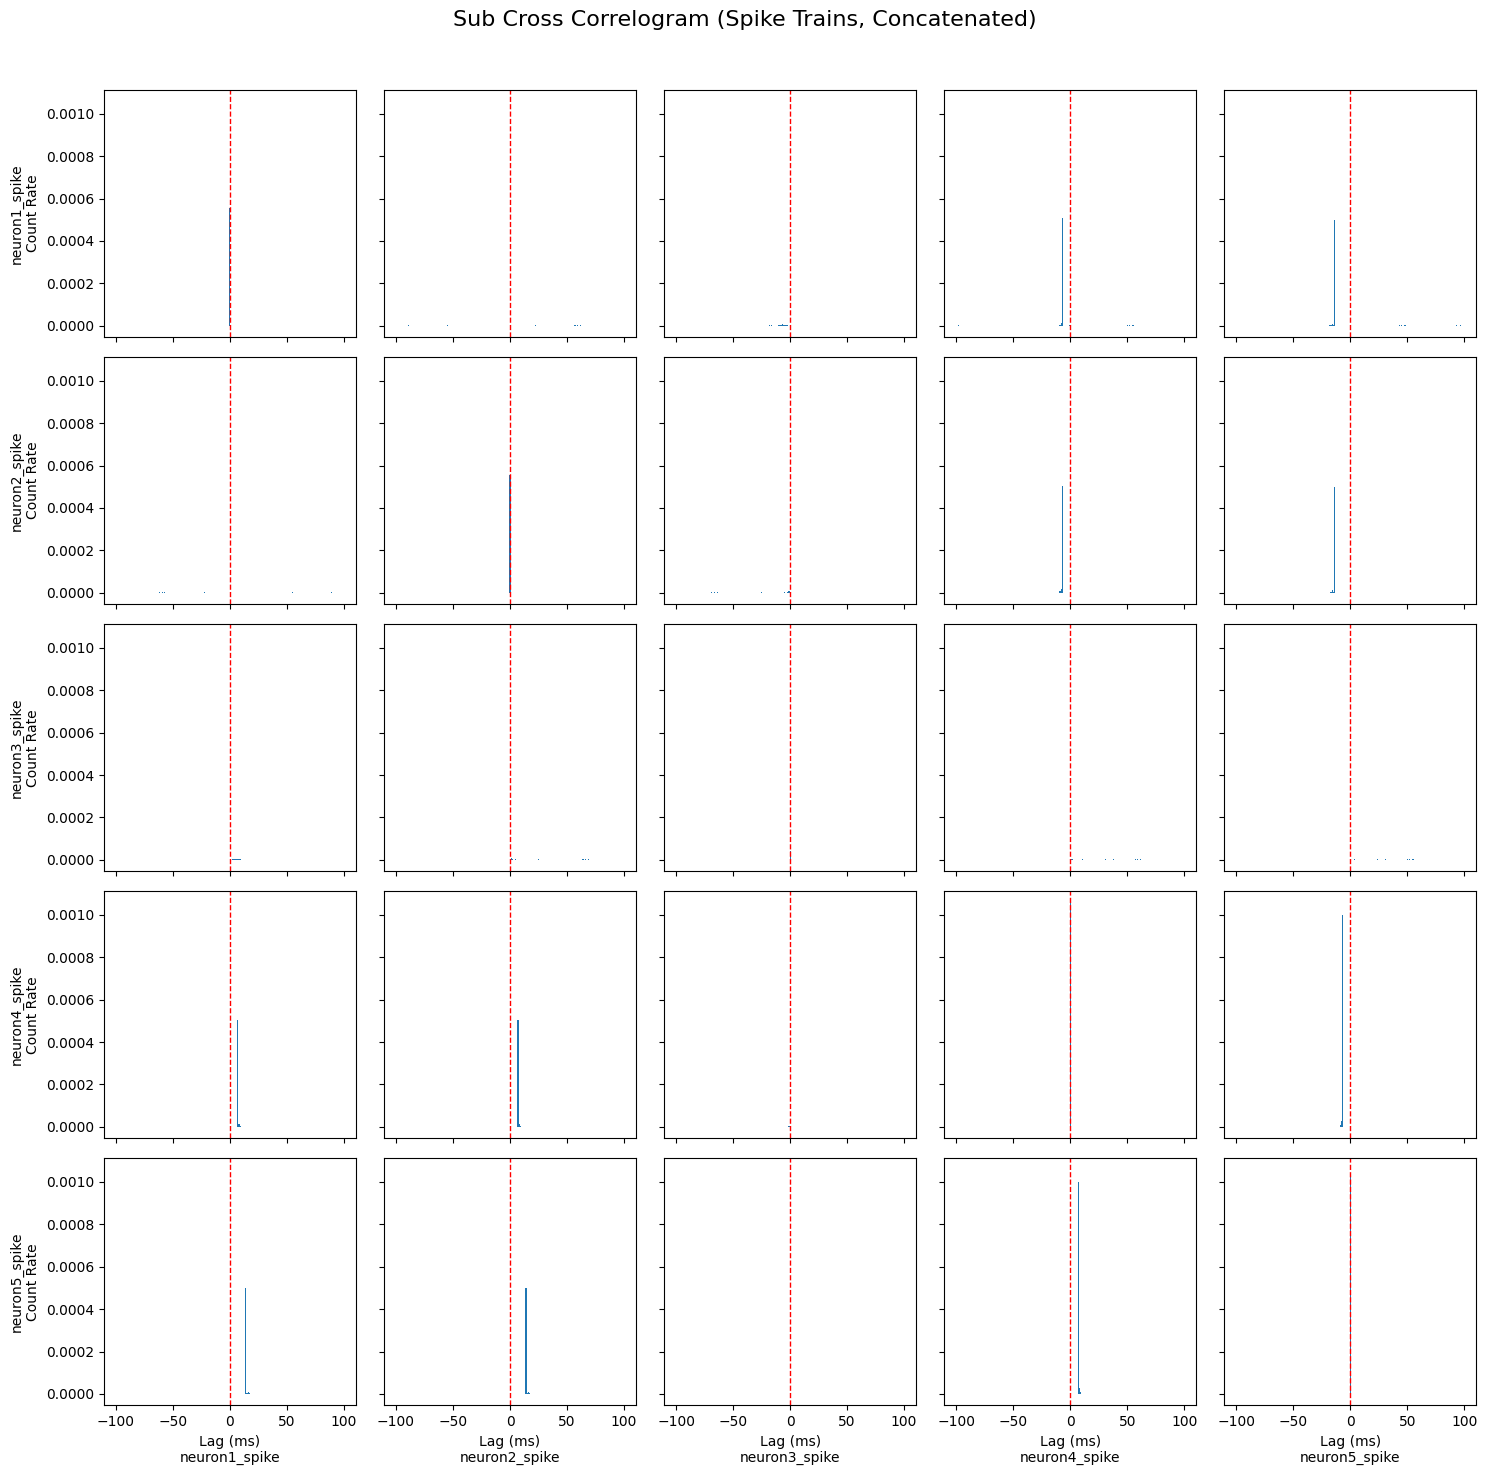

In [107]:
def plot_cross_correlogram(df, spike_columns, max_lag=100, bin_size=1, title_prefix=''):
    num_neurons = len(spike_columns)
    fig, axes = plt.subplots(num_neurons, num_neurons, figsize=(3*num_neurons, 3*num_neurons), sharex=True, sharey=True)
    lags = np.arange(-max_lag, max_lag+1, bin_size)
    for i, col_i in enumerate(spike_columns):
        spikes_i = df[col_i].values
        for j, col_j in enumerate(spike_columns):
            spikes_j = df[col_j].values
            corr = np.correlate(spikes_i - np.mean(spikes_i), spikes_j - np.mean(spikes_j), mode='full')
            center = len(corr) // 2
            corr_lags = corr[center-max_lag:center+max_lag+1]
            corr_rate = corr_lags / df.shape[0]
            ax = axes[i, j] if num_neurons > 1 else axes
            ax.bar(lags, corr_rate, width=1, color='tab:blue')
            if i == num_neurons - 1:
                ax.set_xlabel(f"Lag (ms)\n{col_j}")
            if j == 0:
                ax.set_ylabel(f"{col_i}\nCount Rate")
            ax.axvline(0, color='red', linestyle='--', linewidth=1)
    plt.suptitle(f"{title_prefix} Cross Correlogram (Spike Trains, Concatenated)", fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

print("Cross-correlogram for Ground Truth (Concatenated)")
plot_cross_correlogram(gt_concat_df, spike_columns, max_lag=100, bin_size=1, title_prefix='GT')

print("Cross-correlogram for Submission (Concatenated)")
plot_cross_correlogram(sub_concat_df, spike_columns, max_lag=100, bin_size=1, title_prefix='Sub')

# Output

In [ ]:
rmse_per_neuron_fmt = [float(f"{v:.4g}") for v in rmse_per_neuron]
ks_stats_fmt = [float(f"{v:.4g}") for v in ks_stats]
pearson_corrs_fmt = [float(f"{v:.4g}") for v in pearson_corrs]

summary_df = pd.DataFrame({
    'Neuron': neuron_labels,
    'KS Statistic': ks_stats_fmt,
    'Pearson Correlation': pearson_corrs_fmt,
    'RMSE': rmse_per_neuron_fmt
})

# Normalize the data to come up with a score
min_ks = summary_df['KS Statistic'].min()
max_ks = summary_df['KS Statistic'].max()
summary_df['KS_Normalized'] = 1 - (summary_df['KS Statistic'] - min_ks) / (max_ks - min_ks)

min_pearson = summary_df['Pearson Correlation'].min()
max_pearson = summary_df['Pearson Correlation'].max()
summary_df['Pearson_Normalized'] = (summary_df['Pearson Correlation'] - min_pearson) / (max_pearson - min_pearson)

min_rmse = summary_df['RMSE'].min()
max_rmse = summary_df['RMSE'].max()
summary_df['RMSE_Normalized'] = 1 - (summary_df['RMSE'] - min_rmse) / (max_rmse - min_rmse)

# weights
weight_ks = 0.2
weight_pearson = 0.6
weight_rmse = 0.2

summary_df['Overall Score'] = (
    summary_df['KS_Normalized'] * weight_ks +
    summary_df['Pearson_Normalized'] * weight_pearson +
    summary_df['RMSE_Normalized'] * weight_rmse
) * 100 # Scale to 0-100

summary_df = summary_df.drop(columns=['KS_Normalized', 'Pearson_Normalized', 'RMSE_Normalized'])
summary_df['Overall Score'] = summary_df['Overall Score'].round(2)

print(summary_df)

# note to self.  Min max is often thrownoff by outliers.  Is there a better way to normalize.

     Neuron  KS Statistic  Pearson Correlation      RMSE  Overall Score
0  Neuron 1  0.000000e+00               1.0000  0.000000         100.00
1  Neuron 2  0.000000e+00               1.0000  0.000000         100.00
2  Neuron 3  2.056000e-05               0.6490  0.000067           0.00
3  Neuron 4  0.000000e+00               1.0000  0.000000         100.00
4  Neuron 5  5.556000e-07               0.9997  0.000011          96.28


In [ ]:
charts_folder = 'charts'
chart_files = [f for f in os.listdir(charts_folder) if f.lower().endswith('.png') or f.lower().endswith('.jpg')]

pdf_path = 'charts/all_charts_output.pdf'
with PdfPages(pdf_path) as pdf:
    # Add an introduction and the summary table on the same first page
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.axis('off')
    intro_text = "This report summarizes the performance of different neurons based on key metrics."
    ax.text(0.5, 0.85, intro_text, ha='center', va='center', fontsize=12)
    table = ax.table(cellText=summary_df.values.tolist(),
                     colLabels=list(summary_df.columns),
                     cellLoc='center',
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)
    pdf.savefig(fig)
    plt.close(fig)
    # Add each chart to the PDF This will be structured better later
    for chart_file in chart_files:
        chart_path = os.path.join(charts_folder, chart_file)
        fig = plt.figure(figsize=(8, 6))
        img = mpimg.imread(chart_path)
        plt.imshow(img)
        plt.axis('off')
        plt.title(chart_file)
        pdf.savefig(fig)
        plt.close(fig)

print(f"Charts saved to {pdf_path}")

Charts saved to charts/all_charts_output.pdf
